In [19]:
"""
Refined Data Cleaning and Merging Script
Cleans CompustatNov and CRSPNov data and merges them based on CUSIP and date.
Outputs cleaned dataset with specific requested variables.
"""

import pandas as pd
import numpy as np
from pathlib import Path

# Set data directory
DATA_DIR = Path("/Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack")

print("Loading data files...")
print(f"CompustatNov.csv: {DATA_DIR / 'CompusstatNov.csv'}")
print(f"CRSPNov.csv: {DATA_DIR / 'CSRPNov.csv'}")

# Load Compustat data
comp = pd.read_csv(
    DATA_DIR / "CompusstatNov.csv",
    parse_dates=["datadate"],
    low_memory=False
)

# Load CRSP data
crsp = pd.read_csv(
    DATA_DIR / "CSRPNov.csv",
    parse_dates=["date"],
    low_memory=False
)

print(f"\nCompustat rows: {len(comp):,}")
print(f"CRSP rows: {len(crsp):,}")

# Display column names
print("\nCompustat columns:", comp.columns.tolist())
print("CRSP columns:", crsp.columns.tolist())


Loading data files...
CompustatNov.csv: /Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack/CompusstatNov.csv
CRSPNov.csv: /Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack/CSRPNov.csv

Compustat rows: 517,817
CRSP rows: 3,903,923

Compustat columns: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'cusip', 'sic', 'at', 'dvc', 'ni', 'prstkc']
CRSP columns: ['PERMNO', 'date', 'CUSIP', 'PRC', 'SHROUT', 'sprtrn']


In [20]:
"""
Step 1: Clean Compustat Data
- Trim CUSIP to 8 digits
- Convert date to monthly period-end
- Prepare buyback and dividend amounts
- Calculate return on assets (ROA)
"""

# Clean Compustat data
comp_clean = comp.copy()

# Trim CUSIP to 8 digits
comp_clean["cusip8"] = comp_clean["cusip"].astype(str).str.strip().str.slice(0, 8)

# Convert date to monthly period-end
comp_clean["month"] = comp_clean["datadate"].dt.to_period("M").dt.to_timestamp("M")

# Prepare buyback amount (prstkc is negative in Compustat, make it positive)
# Use abs() to ensure it's always positive regardless of sign
comp_clean["buyback"] = comp_clean["prstkc"].fillna(0.0).abs()

# Prepare dividend amount - ensure it's never negative
# Replace any negative values with 0
comp_clean["dividends"] = comp_clean["dvc"].fillna(0.0)
comp_clean["dividends"] = comp_clean["dividends"].clip(lower=0.0)

# Calculate Return on Assets (ROA) = ni / at
comp_clean["roa"] = comp_clean["ni"] / comp_clean["at"].replace(0, np.nan)

# Select relevant columns from Compustat
comp_final = comp_clean[[
    "cusip8",
    "month",
    "buyback",
    "dividends",
    "sic",
    "ni",  # net income
    "at",  # total assets (for ROA calculation)
    "roa"
]].copy()

print(f"Compustat cleaned rows: {len(comp_final):,}")
print(f"Unique CUSIPs: {comp_final['cusip8'].nunique():,}")
print(f"Date range: {comp_final['month'].min()} to {comp_final['month'].max()}")

# Display sample
print("\nSample Compustat data:")
display(comp_final.head(10))


Compustat cleaned rows: 517,817
Unique CUSIPs: 42,489
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Sample Compustat data:


,cusip8,month,buyback,dividends,sic,ni,at,roa
0,00016510,1982-12-31,0.000,0.0,5812,NaN,NaN,NaN
1,00035410,1983-12-31,1.200,0.0,5712,1.050,8.529,0.123109
2,00016510,1983-12-31,0.000,0.0,5812,1.135,14.080,0.080611
3,00016510,1984-12-31,0.000,0.0,5812,1.138,16.267,0.069958
4,00016510,1985-12-31,0.009,0.0,5812,2.576,39.495,0.065223
5,00035410,1982-12-31,0.000,0.0,5712,0.929,5.632,0.164950
6,00035410,1984-12-31,0.000,0.0,5712,0.387,8.241,0.046960
7,00035410,1986-01-31,0.000,0.0,5712,0.236,13.990,0.016869
8,00035410,1987-01-31,0.000,0.0,5712,0.793,14.586,0.054367
9,00035410,1988-01-31,0.000,0.0,5712,0.186,16.042,0.011595


In [21]:
"""
Step 2: Clean CRSP Data
- Trim CUSIP to 8 digits
- Convert date to monthly period-end
- Calculate market cap = PRC * SHROUT
- Prepare for merging
"""

# Clean CRSP data
crsp_clean = crsp.copy()

# Trim CUSIP to 8 digits
crsp_clean["cusip8"] = crsp_clean["CUSIP"].astype(str).str.strip().str.slice(0, 8)

# Convert date to monthly period-end
crsp_clean["month"] = crsp_clean["date"].dt.to_period("M").dt.to_timestamp("M")

# Ensure PRC and SHROUT are numeric
crsp_clean["PRC"] = pd.to_numeric(crsp_clean["PRC"], errors="coerce")
crsp_clean["SHROUT"] = pd.to_numeric(crsp_clean["SHROUT"], errors="coerce")

# Make PRC positive (use absolute value - negative prices in CRSP indicate bid prices)
# We want absolute price values for analysis
crsp_clean["PRC"] = crsp_clean["PRC"].abs()

# Calculate market cap = PRC * SHROUT (in thousands, so multiply by 1000)
# PRC is price, SHROUT is shares outstanding in thousands
crsp_clean["market_cap"] = crsp_clean["PRC"] * crsp_clean["SHROUT"] * 1000

# Ensure sprtrn is numeric (equity return)
crsp_clean["sprtrn"] = pd.to_numeric(crsp_clean["sprtrn"], errors="coerce")

# Select relevant columns from CRSP
crsp_final = crsp_clean[[
    "PERMNO",
    "cusip8",
    "month",
    "PRC",
    "market_cap",
    "sprtrn"
]].copy()

# Sort by PERMNO and month for forward return calculations
crsp_final = crsp_final.sort_values(["PERMNO", "month"]).reset_index(drop=True)

print(f"CRSP cleaned rows: {len(crsp_final):,}")
print(f"Unique CUSIPs: {crsp_final['cusip8'].nunique():,}")
print(f"Unique PERMNOs: {crsp_final['PERMNO'].nunique():,}")
print(f"Date range: {crsp_final['month'].min()} to {crsp_final['month'].max()}")

# Display sample
print("\nSample CRSP data:")
display(crsp_final.head(10))


CRSP cleaned rows: 3,903,923
Unique CUSIPs: 34,860
Unique PERMNOs: 34,860
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Sample CRSP data:


,PERMNO,cusip8,month,PRC,market_cap,sprtrn
0,10000,68391610,1985-12-31,NaN,NaN,0.045061
1,10000,68391610,1986-01-31,4.37500,16100000.00,0.002367
2,10000,68391610,1986-02-28,3.25000,11960000.00,0.071489
3,10000,68391610,1986-03-31,4.43750,16330000.00,0.052794
4,10000,68391610,1986-04-30,4.00000,15172000.00,-0.014148
5,10000,68391610,1986-05-31,3.10938,11793878.34,0.050229
6,10000,68391610,1986-06-30,3.09375,11734593.75,0.014110
7,10000,68391610,1986-07-31,2.84375,10786343.75,-0.058683
8,10000,68391610,1986-08-31,1.09375,4148593.75,0.071193
9,10000,68391610,1986-09-30,1.03125,3911531.25,-0.085439


In [22]:
"""
Step 3: Calculate Forward Returns (1y, 2y, 5y)
Using sprtrn (equity return) from CRSP data
"""

def forward_buy_and_hold(df, return_col, horizon):
    """
    Computes the compound return from t+1 through t+horizon for each PERMNO.
    Uses log returns to handle negative values properly.
    
    Parameters:
    -----------
    df : DataFrame
        Data sorted by PERMNO and month
    return_col : str
        Column name for returns
    horizon : int
        Number of months for forward return
    
    Returns:
    --------
    Series with forward returns
    """
    def _calc(series):
        # Convert to log returns
        log_r = np.log1p(series)
        # Start from next month (t+1) and roll forward
        fwd_log = (
            log_r.shift(-1)  # Start at next month
            .rolling(window=horizon, min_periods=horizon)
            .sum()
            .shift(-(horizon - 1))  # Align back to current month
        )
        # Convert back to simple returns
        return np.expm1(fwd_log)
    
    return (
        df.groupby("PERMNO", group_keys=False)[return_col]
        .apply(_calc)
    )

# Calculate forward returns
print("Calculating forward returns...")
crsp_final["ret_1y"] = forward_buy_and_hold(crsp_final, "sprtrn", 12)
crsp_final["ret_2y"] = forward_buy_and_hold(crsp_final, "sprtrn", 24)
crsp_final["ret_5y"] = forward_buy_and_hold(crsp_final, "sprtrn", 60)

print(f"Rows with 1y return: {crsp_final['ret_1y'].notna().sum():,}")
print(f"Rows with 2y return: {crsp_final['ret_2y'].notna().sum():,}")
print(f"Rows with 5y return: {crsp_final['ret_5y'].notna().sum():,}")

# Display sample
print("\nSample CRSP data with forward returns:")
display(crsp_final[["PERMNO", "cusip8", "month", "sprtrn", "ret_1y", "ret_2y", "ret_5y"]].head(10))


Calculating forward returns...
Rows with 1y return: 3,495,203
Rows with 2y return: 3,120,153
Rows with 5y return: 2,254,170

Sample CRSP data with forward returns:


,PERMNO,cusip8,month,sprtrn,ret_1y,ret_2y,ret_5y
0,10000,68391610,1985-12-31,0.045061,0.146204,NaN,NaN
1,10000,68391610,1986-01-31,0.002367,0.294173,NaN,NaN
2,10000,68391610,1986-02-28,0.071489,0.252424,NaN,NaN
3,10000,68391610,1986-03-31,0.052794,0.221014,NaN,NaN
4,10000,68391610,1986-04-30,-0.014148,0.224355,NaN,NaN
5,10000,68391610,1986-05-31,0.050229,0.172833,NaN,NaN
6,10000,68391610,1986-06-30,0.014110,0.211929,NaN,NaN
7,10000,68391610,1986-07-31,-0.058683,NaN,NaN,NaN
8,10000,68391610,1986-08-31,0.071193,NaN,NaN,NaN
9,10000,68391610,1986-09-30,-0.085439,NaN,NaN,NaN


In [23]:
"""
Step 4: Merge Compustat and CRSP data
Merge on CUSIP (8 digits) and month
"""

# Merge Compustat and CRSP
merged = pd.merge(
    comp_final,
    crsp_final,
    on=["cusip8", "month"],
    how="inner",
    suffixes=("_comp", "_crsp")
)

print(f"Merged rows: {len(merged):,}")
print(f"Merge rate: {len(merged) / len(comp_final) * 100:.1f}% of Compustat rows")
print(f"Unique CUSIPs after merge: {merged['cusip8'].nunique():,}")
print(f"Date range: {merged['month'].min()} to {merged['month'].max()}")

# Check for duplicates
dup_check = merged.groupby(["cusip8", "month"]).size()
dup_count = (dup_check > 1).sum()
print(f"\nDuplicate CUSIP-month pairs: {dup_count}")

if dup_count > 0:
    print("\nSample duplicates:")
    display(dup_check[dup_check > 1].head(10))

# Ensure buybacks, dividends, and PRC are non-negative (safety check)
# Clip any negative values to 0 for buybacks and dividends
merged["buyback"] = merged["buyback"].clip(lower=0.0)
merged["dividends"] = merged["dividends"].clip(lower=0.0)

# Ensure PRC is positive (use absolute value)
merged["PRC"] = merged["PRC"].abs()

# Report any issues
negative_buyback = (merged["buyback"] < 0).sum()
negative_dividends = (merged["dividends"] < 0).sum()
negative_prc = (merged["PRC"] < 0).sum()

issues = []
if negative_buyback > 0:
    issues.append(f"{negative_buyback} negative buyback values")
if negative_dividends > 0:
    issues.append(f"{negative_dividends} negative dividend values")
if negative_prc > 0:
    issues.append(f"{negative_prc} negative PRC values")

if issues:
    print(f"\nWARNING: Found {', '.join(issues)}")
    print("These have been corrected (clipped to 0 or made positive).")
else:
    print(f"\n✓ Validation: All buyback, dividend, and PRC values are non-negative")

# Display sample
print("\nSample merged data:")
display(merged.head(10))


Merged rows: 310,888
Merge rate: 60.0% of Compustat rows
Unique CUSIPs after merge: 28,151
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Duplicate CUSIP-month pairs: 34362

Sample duplicates:


cusip8    month     
00086810  2010-12-31    2
          2011-12-31    2
          2012-12-31    2
          2013-12-31    2
          2014-12-31    2
          2015-12-31    2
          2016-12-31    2
          2017-12-31    2
          2018-12-31    2
          2019-12-31    2
dtype: int64


✓ Validation: All buyback, dividend, and PRC values are non-negative

Sample merged data:


,cusip8,month,buyback,dividends,sic,ni,at,roa,PERMNO,PRC,market_cap,sprtrn,ret_1y,ret_2y,ret_5y
0,00035410,1983-12-31,1.200,0.000,5712,1.050,8.529,0.123109,10031,5.3750,14421125.0,-0.008834,0.014007,0.281030,0.683871
1,00016510,1983-12-31,0.000,0.000,5812,1.135,14.080,0.080611,10015,7.5000,26775000.0,-0.008834,0.014007,0.281030,NaN
2,00016510,1984-12-31,0.000,0.000,5812,1.138,16.267,0.069958,10015,3.8125,13610625.0,0.022374,0.263334,NaN,NaN
3,00016510,1985-12-31,0.009,0.000,5812,2.576,39.495,0.065223,10015,10.1250,40378500.0,0.045061,NaN,NaN,NaN
4,00035410,1984-12-31,0.000,0.000,5712,0.387,8.241,0.046960,10031,3.0000,8049000.0,0.022374,0.263334,0.448039,NaN
5,00035410,1986-01-31,0.000,0.000,5712,0.236,13.990,0.016869,10031,4.7500,12744250.0,0.002367,0.294173,0.213855,NaN
6,00035410,1987-01-31,0.000,0.000,5712,0.793,14.586,0.054367,10031,4.6875,12576562.5,0.131767,-0.062061,0.085342,NaN
7,00035410,1988-01-31,0.000,0.000,5712,0.186,16.042,0.011595,10031,3.1250,8384375.0,0.040432,0.157156,NaN,NaN
8,00035410,1989-01-31,0.000,0.000,5712,-7.838,16.280,-0.481450,10031,2.0000,5366000.0,0.071115,NaN,NaN,NaN
9,00036110,1982-05-31,0.518,1.582,5080,1.225,113.653,0.010778,54594,7.0000,27594000.0,-0.039162,0.451465,0.345640,1.592963


In [24]:
"""
Step 5: Classify Companies by Payout Type
Classify each observation as:
- "buyback": Company is buyback-dominant (>= threshold % of total payouts from buybacks)
- "dividend": Company is dividend-dominant (>= threshold % of total payouts from dividends)
- "mixed": Company uses both buybacks and dividends roughly equally
- "no_payout": Company has no meaningful payouts (total <= 0 or below minimum threshold)
"""

# Configuration parameters (can be adjusted)
DOMINANCE_THRESHOLD = 0.70  # % of total payouts that must come from one channel to be "dominant"
MIN_TOTAL_PAYOUT = 0  # Minimum total payout in dollars (can be adjusted or set to 0)

# Calculate total payouts
merged["total_payouts"] = merged["buyback"] + merged["dividends"]

# Calculate payout shares (proportion of total payouts from each source)
# Avoid division by zero for cases with no payouts
merged["buyback_share"] = np.where(
    merged["total_payouts"] > 0,
    merged["buyback"] / merged["total_payouts"],
    np.nan
)
merged["dividend_share"] = np.where(
    merged["total_payouts"] > 0,
    merged["dividends"] / merged["total_payouts"],
    np.nan
)

# Classify payout type
def classify_payout_type(row):
    """
    Classify company based on buyback and dividend amounts.
    
    Returns:
    --------
    str: One of "buyback", "dividend", "mixed", or "no_payout"
    """
    total_payouts = row["total_payouts"]
    
    # Check if no payouts or below minimum threshold
    if total_payouts <= 0 or total_payouts < MIN_TOTAL_PAYOUT:
        return "no_payout"
    
    buyback_share = row["buyback_share"]
    dividend_share = row["dividend_share"]
    
    # Check for dominance
    if buyback_share >= DOMINANCE_THRESHOLD:
        return "buyback"
    elif dividend_share >= DOMINANCE_THRESHOLD:
        return "dividend"
    else:
        # Neither is dominant - classify as mixed
        return "mixed"

# Apply classification
merged["payout_type"] = merged.apply(classify_payout_type, axis=1)

# Summary statistics
print("Payout Type Classification Summary:")
print("=" * 50)
payout_counts = merged["payout_type"].value_counts()
print(payout_counts)
print(f"\nPercentages:")
print(payout_counts / len(merged) * 100)

# Display sample
print("\nSample classified data:")
display(merged[["cusip8", "month", "buyback", "dividends", "total_payouts", 
                "buyback_share", "dividend_share", "payout_type"]].head(20))

# Show examples of each type
print("\nExamples of each payout type:")
for ptype in ["buyback", "dividend", "mixed", "no_payout"]:
    sample = merged[merged["payout_type"] == ptype].head(3)
    if len(sample) > 0:
        print(f"\n{ptype.upper()} examples:")
        display(sample[["cusip8", "month", "buyback", "dividends", "total_payouts", 
                        "buyback_share", "dividend_share", "payout_type"]])


Payout Type Classification Summary:
payout_type
no_payout    154376
dividend      90851
buyback       49906
mixed         15755
Name: count, dtype: int64

Percentages:
payout_type
no_payout    49.656468
dividend     29.223064
buyback      16.052726
mixed         5.067741
Name: count, dtype: float64

Sample classified data:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
0,00035410,1983-12-31,1.200,0.000,1.200,1.000000,0.000000,buyback
1,00016510,1983-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
2,00016510,1984-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
3,00016510,1985-12-31,0.009,0.000,0.009,1.000000,0.000000,buyback
4,00035410,1984-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
5,00035410,1986-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
6,00035410,1987-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
7,00035410,1988-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
8,00035410,1989-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
9,00036110,1982-05-31,0.518,1.582,2.100,0.246667,0.753333,dividend



Examples of each payout type:

BUYBACK examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
0,00035410,1983-12-31,1.200,0.0,1.200,1.0,0.0,buyback
3,00016510,1985-12-31,0.009,0.0,0.009,1.0,0.0,buyback
28,00087230,1987-12-31,0.004,0.0,0.004,1.0,0.0,buyback



DIVIDEND examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
9,00036110,1982-05-31,0.518,1.582,2.100,0.246667,0.753333,dividend
10,00036110,1983-05-31,0.211,1.727,1.938,0.108875,0.891125,dividend
11,00036110,1984-05-31,0.003,1.965,1.968,0.001524,0.998476,dividend



MIXED examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
25,00036110,1997-05-31,8.080,7.976,16.056,0.503239,0.496761,mixed
27,00036110,1999-05-31,7.558,9.375,16.933,0.446347,0.553653,mixed
29,00036110,2000-05-31,10.530,9.218,19.748,0.533219,0.466781,mixed



NO_PAYOUT examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
1,00016510,1983-12-31,0.0,0.0,0.0,NaN,NaN,no_payout
2,00016510,1984-12-31,0.0,0.0,0.0,NaN,NaN,no_payout
4,00035410,1984-12-31,0.0,0.0,0.0,NaN,NaN,no_payout


In [25]:
"""
Step 6: Select and organize final columns
Keep only the requested variables:
- CUSIP (cusip8)
- PRC
- market_cap
- ret_1y, ret_2y, ret_5y
- buyback
- dividends
- sic
- ni (net income)
- roa (return on assets)
- sprtrn (equity return)
- payout_type (classification: buyback, dividend, mixed, or no_payout)
Note: month is included for time-series analysis but can be removed if not needed
"""

# Select final columns in requested order (including month for time-series analysis)
final_data = merged[[
    "cusip8",
    "month",
    "PRC",
    "market_cap",
    "ret_1y",
    "ret_2y",
    "ret_5y",
    "buyback",
    "dividends",
    "sic",
    "ni",
    "roa",
    "sprtrn",
    "payout_type"  # Add payout classification
]].copy()

# Rename cusip8 to CUSIP for consistency
final_data = final_data.rename(columns={"cusip8": "CUSIP"})

# Sort by CUSIP and month
final_data = final_data.sort_values(["CUSIP", "month"]).reset_index(drop=True)

print(f"Final dataset shape: {final_data.shape}")
print(f"\nFinal columns:")
print(final_data.columns.tolist())

print(f"\nData summary:")
print(f"Total rows: {len(final_data):,}")
print(f"Unique CUSIPs: {final_data['CUSIP'].nunique():,}")
print(f"Date range: {final_data['month'].min()} to {final_data['month'].max()}")
print(f"\nMissing values:")
display(final_data.isnull().sum())

# Display sample
print("\nSample final data:")
display(final_data.head(20))

# Display summary statistics
print("\nSummary statistics:")
display(final_data.describe())


Final dataset shape: (310888, 14)

Final columns:
['CUSIP', 'month', 'PRC', 'market_cap', 'ret_1y', 'ret_2y', 'ret_5y', 'buyback', 'dividends', 'sic', 'ni', 'roa', 'sprtrn', 'payout_type']

Data summary:
Total rows: 310,888
Unique CUSIPs: 28,151
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Missing values:


CUSIP               0
month               0
PRC              5097
market_cap       5097
ret_1y          25305
ret_2y          54003
ret_5y         122712
buyback             0
dividends           0
sic                 0
ni              88555
roa             88680
sprtrn              0
payout_type         0
dtype: int64


Sample final data:


,CUSIP,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn,payout_type
0,00002130,1991-06-30,5.12500,32641125.0,0.099633,0.213842,0.806849,0.000,0.000,2020,-0.326,-0.034889,-0.047893,no_payout
1,00002130,1992-06-30,2.50000,19285000.0,0.103861,0.088524,1.168722,0.000,0.000,2020,-1.860,-0.102400,-0.017359,no_payout
2,00002130,1993-06-30,2.31250,18261812.5,-0.013894,0.209131,NaN,0.000,0.000,2020,-0.469,-0.024775,0.000755,no_payout
3,00002130,1994-06-30,0.93750,7923750.0,0.226168,0.509511,NaN,0.000,0.000,2020,-2.209,-0.115921,-0.026812,no_payout
4,00002130,1995-06-30,0.59375,5018375.0,0.231080,0.624860,NaN,0.000,0.000,2020,-1.353,-0.070968,0.021279,no_payout
5,00002130,1996-06-30,0.68750,5810750.0,0.319866,NaN,NaN,0.000,0.000,2020,-2.285,-0.124557,0.002257,no_payout
6,00002130,1997-06-30,0.21875,1848875.0,NaN,NaN,NaN,0.000,0.000,2020,-3.977,-0.284498,0.043453,no_payout
7,00016510,1983-12-31,7.50000,26775000.0,0.014007,0.281030,NaN,0.000,0.000,5812,1.135,0.080611,-0.008834,no_payout
8,00016510,1984-12-31,3.81250,13610625.0,0.263334,NaN,NaN,0.000,0.000,5812,1.138,0.069958,0.022374,no_payout
9,00016510,1985-12-31,10.12500,40378500.0,NaN,NaN,NaN,0.009,0.000,5812,2.576,0.065223,0.045061,buyback



Summary statistics:


,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn
count,310888,305791.000000,3.057910e+05,285583.000000,256885.000000,188176.000000,310888.000000,310888.000000,310888.000000,222333.000000,222208.000000,310888.000000
mean,2005-04-21 07:10:36.792671104,26.741788,2.998779e+09,0.107056,0.217326,0.602151,60.748392,70.689748,5271.308159,178.396482,-0.076808,0.010231
min,1982-01-31 00:00:00,0.030000,5.031320e+03,-0.447561,-0.477479,-0.357965,0.000000,0.000000,100.000000,-99289.000000,-1719.000000,-0.217630
25%,1995-01-31 00:00:00,7.000000,4.079342e+07,0.014007,0.087391,0.235365,0.000000,0.000000,3672.000000,-2.441000,-0.036007,-0.008628
50%,2004-12-31 00:00:00,15.860000,1.826250e+08,0.127828,0.189043,0.668932,0.000000,0.000000,6020.000000,4.238000,0.018043,0.012299
75%,2015-12-31 00:00:00,30.437500,9.083374e+08,0.234799,0.430307,0.866151,0.070000,5.332000,6722.000000,44.641000,0.063216,0.034637
max,2024-12-31 00:00:00,8178.899900,3.522211e+12,0.537143,0.805524,2.425361,100390.000000,67643.805000,9997.000000,100118.000000,390.720000,0.131767
std,NaN,66.754129,2.361040e+10,0.165703,0.251350,0.521720,788.029118,499.188638,1859.179817,1538.923986,4.444668,0.038832


In [26]:
"""
Step 7: Data Quality Checks and Final Cleanup
"""

# Data quality checks
print("Data Quality Checks:")
print("=" * 50)

# Check for negative market caps (should not happen)
negative_mcap = (final_data["market_cap"] < 0).sum()
print(f"Negative market caps: {negative_mcap}")

# Check for negative buybacks, dividends, and PRC (should not happen)
negative_buyback = (final_data["buyback"] < 0).sum()
negative_dividends = (final_data["dividends"] < 0).sum()
negative_prc = (final_data["PRC"] < 0).sum()
print(f"Negative buybacks: {negative_buyback}")
print(f"Negative dividends: {negative_dividends}")
print(f"Negative PRC: {negative_prc}")

# Final safeguard: ensure no negative values
final_data["buyback"] = final_data["buyback"].clip(lower=0.0)
final_data["dividends"] = final_data["dividends"].clip(lower=0.0)
final_data["PRC"] = final_data["PRC"].abs()  # Ensure PRC is always positive

# Check for extreme values
print(f"\nMarket cap range: ${final_data['market_cap'].min():,.0f} to ${final_data['market_cap'].max():,.0f}")
print(f"Net income range: ${final_data['ni'].min():,.0f} to ${final_data['ni'].max():,.0f}")

# Check date consistency
print(f"\nDate range: {final_data['month'].min()} to {final_data['month'].max()}")
print(f"Total months: {final_data['month'].nunique()}")

# Check CUSIP format
print(f"\nCUSIP length check:")
cusip_lengths = final_data["CUSIP"].str.len()
print(cusip_lengths.value_counts().sort_index())

# Payout type distribution
print(f"\nPayout type distribution:")
payout_dist = final_data["payout_type"].value_counts()
print(payout_dist)
print(f"\nPercentages:")
print(payout_dist / len(final_data) * 100)

# Final dataset info
print(f"\n{'='*50}")
print(f"FINAL CLEANED DATASET READY")
print(f"{'='*50}")
print(f"Shape: {final_data.shape}")
print(f"Columns: {list(final_data.columns)}")
print(f"\nFirst few rows:")
display(final_data.head(10))


Data Quality Checks:
Negative market caps: 0
Negative buybacks: 0
Negative dividends: 0
Negative PRC: 0

Market cap range: $5,031 to $3,522,211,138,000
Net income range: $-99,289 to $100,118

Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00
Total months: 516

CUSIP length check:
CUSIP
8    310888
Name: count, dtype: int64

Payout type distribution:
payout_type
no_payout    154376
dividend      90851
buyback       49906
mixed         15755
Name: count, dtype: int64

Percentages:
payout_type
no_payout    49.656468
dividend     29.223064
buyback      16.052726
mixed         5.067741
Name: count, dtype: float64

FINAL CLEANED DATASET READY
Shape: (310888, 14)
Columns: ['CUSIP', 'month', 'PRC', 'market_cap', 'ret_1y', 'ret_2y', 'ret_5y', 'buyback', 'dividends', 'sic', 'ni', 'roa', 'sprtrn', 'payout_type']

First few rows:


,CUSIP,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn,payout_type
0,00002130,1991-06-30,5.12500,32641125.0,0.099633,0.213842,0.806849,0.000,0.0,2020,-0.326,-0.034889,-0.047893,no_payout
1,00002130,1992-06-30,2.50000,19285000.0,0.103861,0.088524,1.168722,0.000,0.0,2020,-1.860,-0.102400,-0.017359,no_payout
2,00002130,1993-06-30,2.31250,18261812.5,-0.013894,0.209131,NaN,0.000,0.0,2020,-0.469,-0.024775,0.000755,no_payout
3,00002130,1994-06-30,0.93750,7923750.0,0.226168,0.509511,NaN,0.000,0.0,2020,-2.209,-0.115921,-0.026812,no_payout
4,00002130,1995-06-30,0.59375,5018375.0,0.231080,0.624860,NaN,0.000,0.0,2020,-1.353,-0.070968,0.021279,no_payout
5,00002130,1996-06-30,0.68750,5810750.0,0.319866,NaN,NaN,0.000,0.0,2020,-2.285,-0.124557,0.002257,no_payout
6,00002130,1997-06-30,0.21875,1848875.0,NaN,NaN,NaN,0.000,0.0,2020,-3.977,-0.284498,0.043453,no_payout
7,00016510,1983-12-31,7.50000,26775000.0,0.014007,0.281030,NaN,0.000,0.0,5812,1.135,0.080611,-0.008834,no_payout
8,00016510,1984-12-31,3.81250,13610625.0,0.263334,NaN,NaN,0.000,0.0,5812,1.138,0.069958,0.022374,no_payout
9,00016510,1985-12-31,10.12500,40378500.0,NaN,NaN,NaN,0.009,0.0,5812,2.576,0.065223,0.045061,buyback


PART 1: OVERALL SUMMARY STATISTICS BY PAYOUT TYPE

Total observations: 310,888
Date range: 1982-01 to 2024-12




,n_observations,n_firms,avg_market_cap_millions,avg_roa_pct,pct_of_total
payout_type,,,,,
buyback,49906,11521,4610.61,-2.100,16.05
dividend,90851,8675,3692.13,8.357,29.22
mixed,15755,4043,13185.99,5.647,5.07
no_payout,154376,23674,985.21,-24.622,49.66



FORMATTED SUMMARY BY PAYOUT TYPE (OVERALL)

BUYBACK:
  • Number of observations: 49,906.0 (16.1% of total)
  • Number of unique firms: 11,521.0
  • Average market cap: $4,610.61 million
  • Average ROA: -2.100%

DIVIDEND:
  • Number of observations: 90,851.0 (29.2% of total)
  • Number of unique firms: 8,675.0
  • Average market cap: $3,692.13 million
  • Average ROA: 8.357%

MIXED:
  • Number of observations: 15,755.0 (5.1% of total)
  • Number of unique firms: 4,043.0
  • Average market cap: $13,185.99 million
  • Average ROA: 5.647%

NO PAYOUT:
  • Number of observations: 154,376.0 (49.7% of total)
  • Number of unique firms: 23,674.0
  • Average market cap: $985.21 million
  • Average ROA: -24.622%

INDUSTRY BREAKDOWN BY PAYOUT TYPE (Number of Firms)

This table shows how many unique firms (by CUSIP) fall into each SIC industry category:



industry,"Agriculture, Forestry, And Fishing",Mining,Construction,Manufacturing,"Transportation, Communications, Electric, Gas, And Sanitary Services",Wholesale Trade,Retail Trade,"Finance, Insurance, And Real Estate",Services,Public Administration,Unknown
payout_type,,,,,,,,,,,
buyback,0,664,140,4387,792,388,717,1752,2585,96,0
dividend,0,457,98,2491,801,281,432,3123,950,42,0
mixed,0,184,41,1387,400,124,192,1309,392,14,0
no_payout,0,1106,206,6589,1153,562,993,9130,3664,271,0



INDUSTRY BREAKDOWN BY PAYOUT TYPE (Formatted)

BUYBACK - Firms by Industry:
  • Mining: 664 firms
  • Construction: 140 firms
  • Manufacturing: 4,387 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 792 firms
  • Wholesale Trade: 388 firms
  • Retail Trade: 717 firms
  • Finance, Insurance, And Real Estate: 1,752 firms
  • Services: 2,585 firms
  • Public Administration: 96 firms

DIVIDEND - Firms by Industry:
  • Mining: 457 firms
  • Construction: 98 firms
  • Manufacturing: 2,491 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 801 firms
  • Wholesale Trade: 281 firms
  • Retail Trade: 432 firms
  • Finance, Insurance, And Real Estate: 3,123 firms
  • Services: 950 firms
  • Public Administration: 42 firms

MIXED - Firms by Industry:
  • Mining: 184 firms
  • Construction: 41 firms
  • Manufacturing: 1,387 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 400 firms
  • Wholesale Trade: 124 

,payout_type,period,n_observations,n_firms,avg_market_cap_millions,avg_roa_pct,pct_of_total
0,buyback,1982-01,145,145,61.93,0.444,12.27
1,dividend,1982-01,424,421,142.70,8.228,35.87
2,mixed,1982-01,43,43,125.77,5.741,3.64
3,no_payout,1982-01,570,568,32.15,-8.347,48.22
4,buyback,1982-07,342,342,93.13,0.861,10.40
...,...,...,...,...,...,...,...
339,no_payout,2024-01,384,376,5485.95,-68.648,47.47
340,buyback,2024-07,1459,1459,14110.27,-8.905,16.58
341,dividend,2024-07,1643,1232,13081.40,5.692,18.67
342,mixed,2024-07,476,476,25879.76,5.008,5.41



FORMATTED TIME-SERIES SUMMARY (SAMPLE - EVERY 10 PERIODS)

PERIOD: 1982-01

BUYBACK:
  • Observations: 145 (12.3% of period)
  • Unique firms: 145
  • Avg market cap: $61.93M
  • Avg ROA: 0.444%

DIVIDEND:
  • Observations: 424 (35.9% of period)
  • Unique firms: 421
  • Avg market cap: $142.70M
  • Avg ROA: 8.228%

MIXED:
  • Observations: 43 (3.6% of period)
  • Unique firms: 43
  • Avg market cap: $125.77M
  • Avg ROA: 5.741%

NO PAYOUT:
  • Observations: 570 (48.2% of period)
  • Unique firms: 568
  • Avg market cap: $32.15M
  • Avg ROA: -8.347%

PERIOD: 1987-01

BUYBACK:
  • Observations: 244 (15.5% of period)
  • Unique firms: 244
  • Avg market cap: $170.38M
  • Avg ROA: -4.387%

DIVIDEND:
  • Observations: 317 (20.1% of period)
  • Unique firms: 312
  • Avg market cap: $523.73M
  • Avg ROA: 5.225%

MIXED:
  • Observations: 58 (3.7% of period)
  • Unique firms: 58
  • Avg market cap: $641.38M
  • Avg ROA: 5.364%

NO PAYOUT:
  • Observations: 955 (60.7% of period)
  • Unique fir

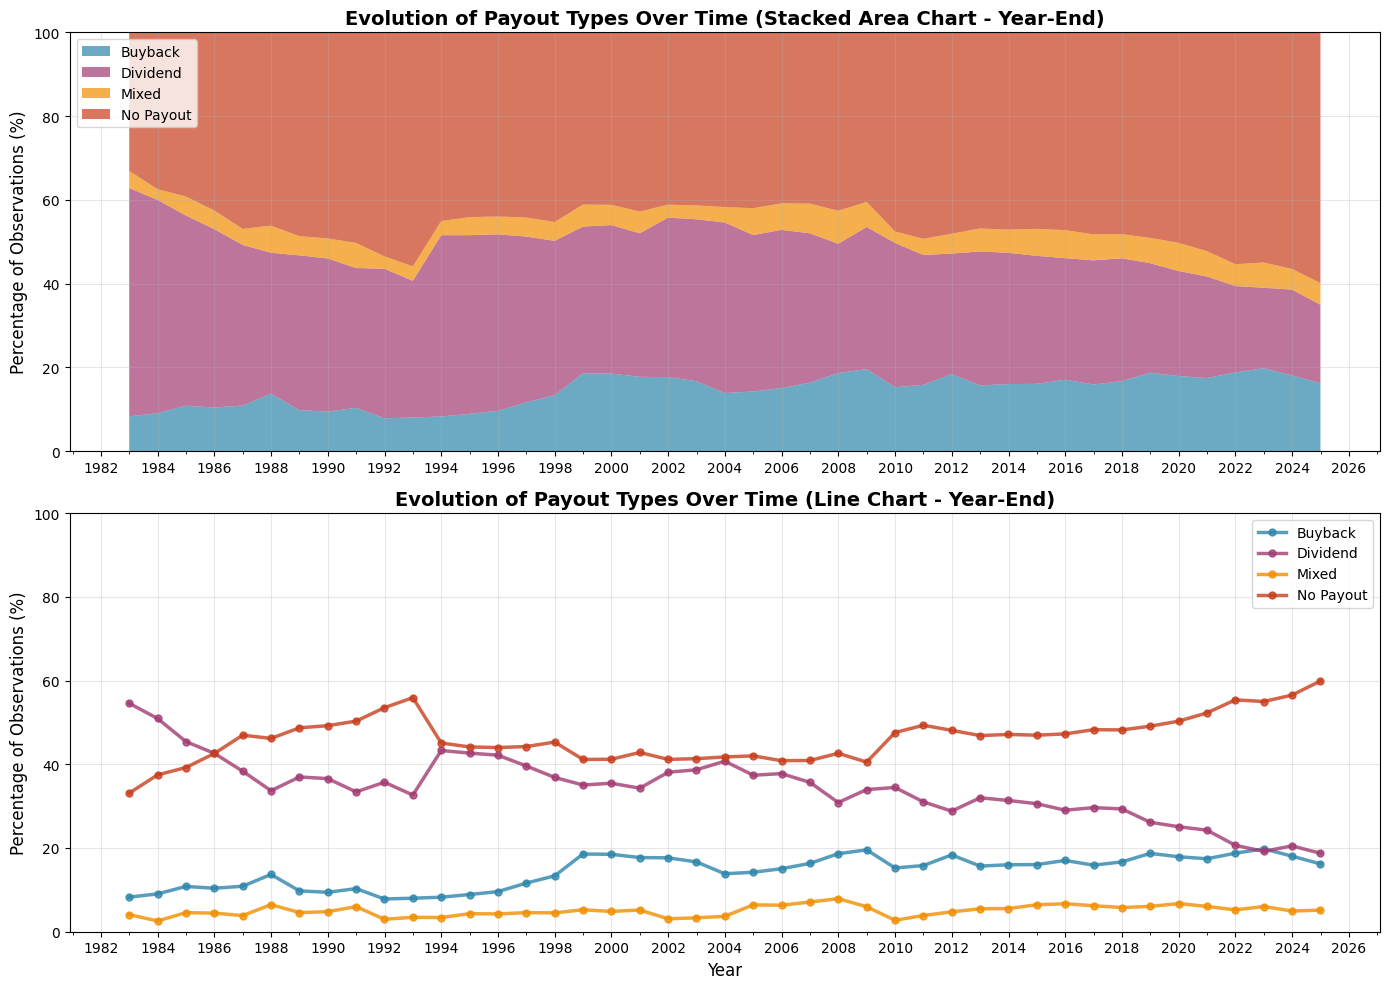


INDUSTRY EVOLUTION BY PAYOUT TYPE


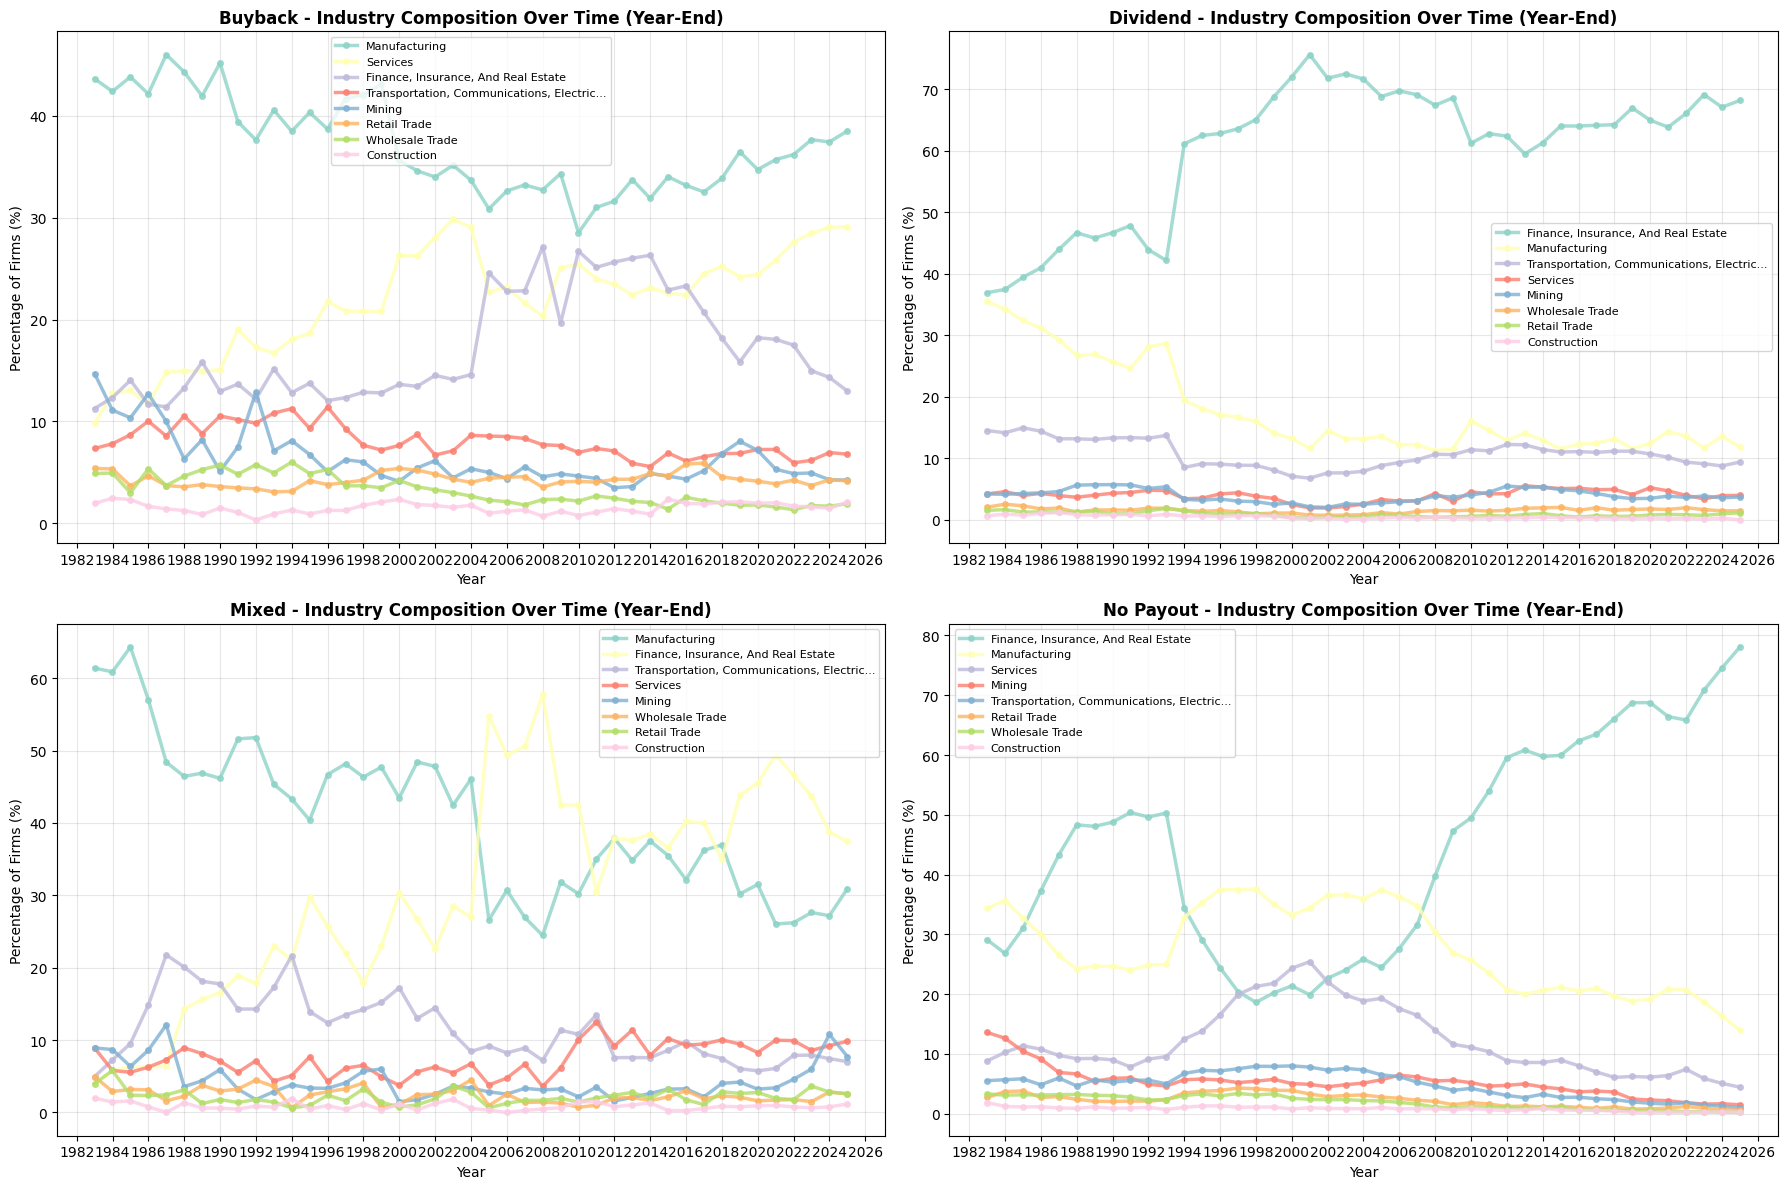


SIZE AND ROA EVOLUTION BY PAYOUT TYPE - YEAR-END

Calculated means for 172 year-payout type combinations
Years covered: 1982 to 2024

Displaying Graphs 4 & 5...



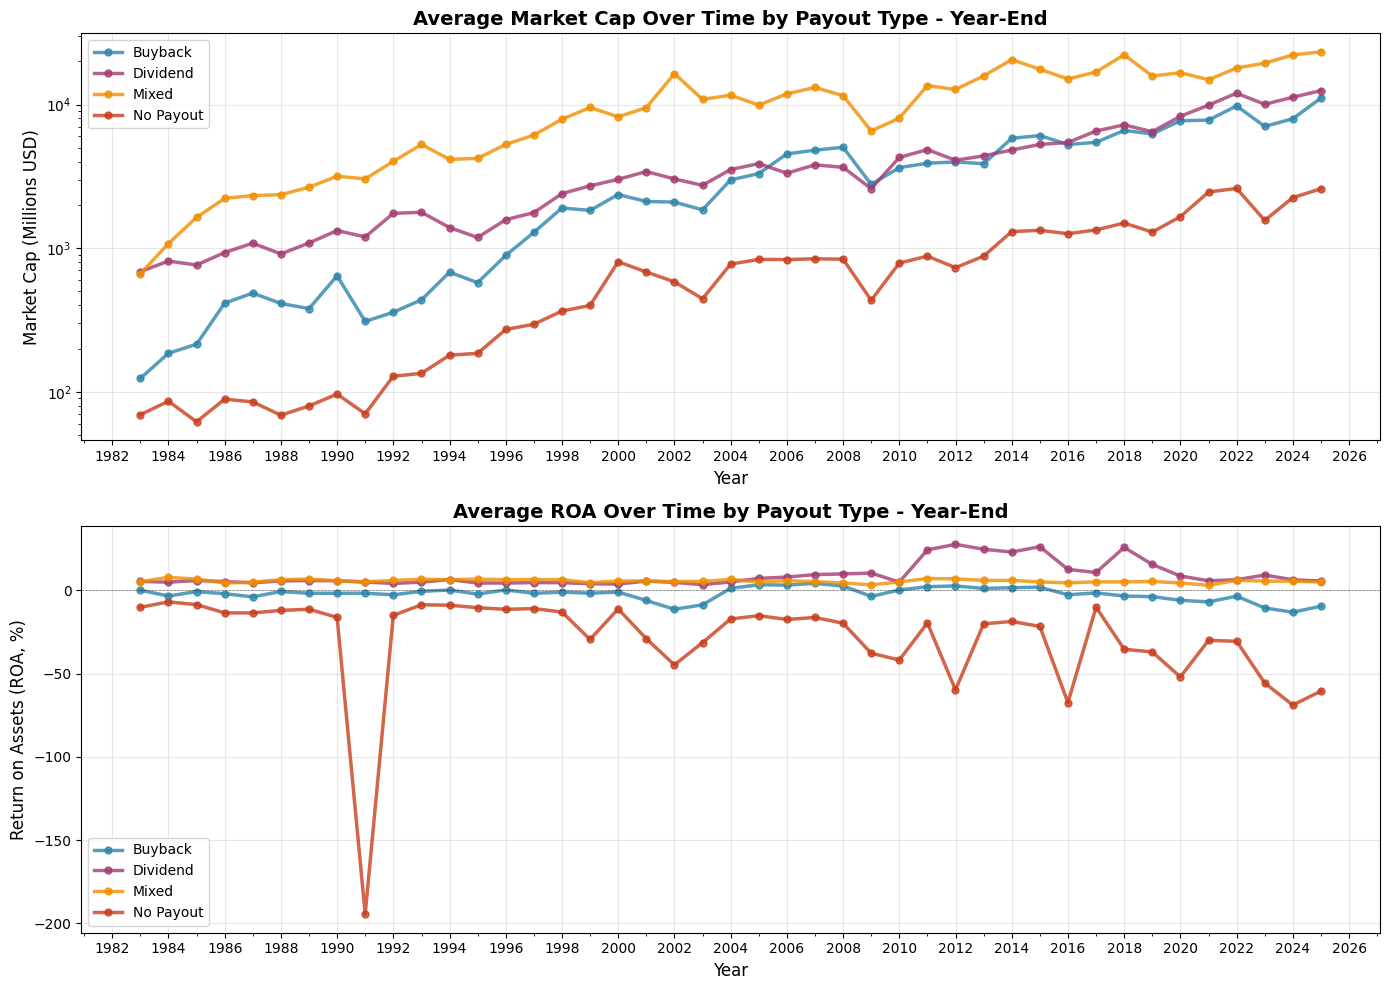


Summary Statistics from Visualizations:
Average percentage by payout type over all year-end periods:
  • Buyback: 14.42%
  • Dividend: 34.28%
  • Mixed: 5.01%
  • No Payout: 46.28%

Summary dataframes saved:
  - 'summary_stats': Overall summary by payout type
  - 'time_summary': Time-series summary (6-month periods)
  - 'industry_firm_counts': Number of firms by payout type and industry


In [36]:
"""
Step 8: Summary Statistics by Payout Type (Overall and Time-Series)
Create comprehensive summary statistics for each payout type:
- Number of observations
- Number of unique firms (CUSIPs)
- Average market capitalization (firm size)
- Industry breakdown by SIC code categories
- Average return on assets (ROA)
"""

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Define payout order
payout_order = ["buyback", "dividend", "mixed", "no_payout"]

# ============================================================================
# SIC CODE TO INDUSTRY MAPPING
# ============================================================================

def map_sic_to_industry(sic_code):
    """
    Map SIC code to industry category based on standard classifications.
    Uses only the first 2 digits of the SIC code.
    
    Parameters:
    -----------
    sic_code : numeric
        Standard Industrial Classification code
    
    Returns:
    --------
    str : Industry category name
    """
    if pd.isna(sic_code):
        return "Unknown"
    
    try:
        # Convert to string to extract first 2 digits
        sic_str = str(int(sic_code))
        # Get first 2 digits, pad with zeros if needed
        if len(sic_str) >= 2:
            sic_2digit = int(sic_str[:2])
        else:
            # If less than 2 digits, pad with zero
            sic_2digit = int(sic_str.zfill(2)[:2])
    except:
        return "Unknown"
    
    # Map based on first 2 digits
    if 1 <= sic_2digit <= 9:
        return "Agriculture, Forestry, And Fishing"
    elif 10 <= sic_2digit <= 14:
        return "Mining"
    elif 15 <= sic_2digit <= 17:
        return "Construction"
    elif 20 <= sic_2digit <= 39:
        return "Manufacturing"
    elif 40 <= sic_2digit <= 49:
        return "Transportation, Communications, Electric, Gas, And Sanitary Services"
    elif 50 <= sic_2digit <= 51:
        return "Wholesale Trade"
    elif 52 <= sic_2digit <= 59:
        return "Retail Trade"
    elif 60 <= sic_2digit <= 67:
        return "Finance, Insurance, And Real Estate"
    elif 70 <= sic_2digit <= 89:
        return "Services"
    elif 90 <= sic_2digit <= 99:
        return "Public Administration"
    else:
        return "Unknown"

# Apply industry mapping to final_data
final_data["industry"] = final_data["sic"].apply(map_sic_to_industry)

# Industry order for consistent display
industry_order = [
    "Agriculture, Forestry, And Fishing",
    "Mining",
    "Construction",
    "Manufacturing",
    "Transportation, Communications, Electric, Gas, And Sanitary Services",
    "Wholesale Trade",
    "Retail Trade",
    "Finance, Insurance, And Real Estate",
    "Services",
    "Public Administration",
    "Unknown"
]

# ============================================================================
# PART 1: OVERALL SUMMARY STATISTICS
# ============================================================================

print("=" * 80)
print("PART 1: OVERALL SUMMARY STATISTICS BY PAYOUT TYPE")
print("=" * 80)

# Calculate overall summary statistics by payout type
summary_stats = final_data.groupby("payout_type").agg({
    "CUSIP": ["count", "nunique"],  # Number of observations and unique firms
    "market_cap": "mean",  # Average market cap
    "roa": "mean"  # Average return on assets
})

# Calculate industry breakdown (firms per industry category by payout type)
industry_firm_counts = final_data.groupby(["payout_type", "industry"])["CUSIP"].nunique().unstack(fill_value=0)
industry_firm_counts = industry_firm_counts.reindex(columns=industry_order, fill_value=0)
industry_firm_counts = industry_firm_counts.reindex(payout_order)

# Flatten multi-index column names
if isinstance(summary_stats.columns, pd.MultiIndex):
    summary_stats.columns = ["_".join(col).strip() for col in summary_stats.columns.values]
    # Rename to cleaner names
    summary_stats = summary_stats.rename(columns={
        "CUSIP_count": "n_observations",
        "CUSIP_nunique": "n_firms",
        "market_cap_mean": "avg_market_cap_millions",
        "roa_mean": "avg_roa_pct"
    })
else:
    # Fallback if columns are already flat
    summary_stats.columns = ["n_observations", "n_firms", "avg_market_cap_millions", "avg_roa_pct"]

# Format the summary statistics
summary_stats["avg_market_cap_millions"] = (summary_stats["avg_market_cap_millions"] / 1_000_000).round(2)
summary_stats["avg_roa_pct"] = (summary_stats["avg_roa_pct"] * 100).round(3)

# Reorder columns
summary_stats = summary_stats[[
    "n_observations",
    "n_firms",
    "avg_market_cap_millions",
    "avg_roa_pct"
]]

# Calculate percentages of total observations
total_obs = summary_stats["n_observations"].sum()
summary_stats["pct_of_total"] = (summary_stats["n_observations"] / total_obs * 100).round(2)

# Sort by payout type
summary_stats = summary_stats.reindex(payout_order)

# Display overall summary
print(f"\nTotal observations: {total_obs:,}")
print(f"Date range: {final_data['month'].min().strftime('%Y-%m')} to {final_data['month'].max().strftime('%Y-%m')}")
print(f"\n{'=' * 80}\n")
display(summary_stats)

# Formatted summary
print("\n" + "=" * 80)
print("FORMATTED SUMMARY BY PAYOUT TYPE (OVERALL)")
print("=" * 80)

for ptype in payout_order:
    if ptype in summary_stats.index:
        stats = summary_stats.loc[ptype]
        print(f"\n{ptype.upper().replace('_', ' ')}:")
        print(f"  • Number of observations: {stats['n_observations']:,} ({stats['pct_of_total']:.1f}% of total)")
        print(f"  • Number of unique firms: {stats['n_firms']:,}")
        print(f"  • Average market cap: ${stats['avg_market_cap_millions']:,.2f} million")
        print(f"  • Average ROA: {stats['avg_roa_pct']:.3f}%")

# Display industry breakdown
print("\n" + "=" * 80)
print("INDUSTRY BREAKDOWN BY PAYOUT TYPE (Number of Firms)")
print("=" * 80)
print("\nThis table shows how many unique firms (by CUSIP) fall into each SIC industry category:")
print("")
display(industry_firm_counts)

# Show industry breakdown in formatted way
print("\n" + "=" * 80)
print("INDUSTRY BREAKDOWN BY PAYOUT TYPE (Formatted)")
print("=" * 80)
for ptype in payout_order:
    if ptype in industry_firm_counts.index:
        print(f"\n{ptype.upper().replace('_', ' ')} - Firms by Industry:")
        industry_counts = industry_firm_counts.loc[ptype]
        for industry in industry_order:
            count = industry_counts[industry]
            if count > 0:
                print(f"  • {industry}: {count:,} firms")

# ============================================================================
# PART 2: TIME-SERIES SUMMARY (EVERY 6 MONTHS)
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: TIME-SERIES SUMMARY BY PAYOUT TYPE (6-MONTH PERIODS)")
print("=" * 80)

# Create 6-month periods (ensure industry column exists)
final_data_copy = final_data.copy()
if "industry" not in final_data_copy.columns:
    final_data_copy["industry"] = final_data_copy["sic"].apply(map_sic_to_industry)
final_data_copy["year"] = final_data_copy["month"].dt.year
final_data_copy["month_num"] = final_data_copy["month"].dt.month
final_data_copy["period"] = final_data_copy["year"].astype(str) + "-" + (
    ((final_data_copy["month_num"] - 1) // 6) * 6 + 1
).astype(str).str.zfill(2)

# Sort periods chronologically
periods = sorted(final_data_copy["period"].unique())

print(f"\nTotal periods: {len(periods)}")
print(f"Period range: {periods[0]} to {periods[-1]}")
print(f"\n{'=' * 80}\n")

# Calculate summary statistics for each 6-month period and payout type
time_summary_list = []

for period in periods:
    period_data = final_data_copy[final_data_copy["period"] == period]
    
    if len(period_data) == 0:
        continue
    
    period_stats = period_data.groupby("payout_type").agg({
        "CUSIP": ["count", "nunique"],
        "market_cap": "mean",
        "roa": "mean"
    })
    
    # Flatten multi-index column names
    if isinstance(period_stats.columns, pd.MultiIndex):
        period_stats.columns = ["_".join(col).strip() for col in period_stats.columns.values]
        # Rename to cleaner names
        period_stats = period_stats.rename(columns={
            "CUSIP_count": "n_observations",
            "CUSIP_nunique": "n_firms",
            "market_cap_mean": "avg_market_cap_millions",
            "roa_mean": "avg_roa_pct"
        })
    else:
        period_stats.columns = ["n_observations", "n_firms", "avg_market_cap_millions", "avg_roa_pct"]
    
    # Format
    period_stats["avg_market_cap_millions"] = (period_stats["avg_market_cap_millions"] / 1_000_000).round(2)
    period_stats["avg_roa_pct"] = (period_stats["avg_roa_pct"] * 100).round(3)
    
    # Add period column
    period_stats["period"] = period
    
    # Calculate percentage of total for this period
    period_total = period_stats["n_observations"].sum()
    period_stats["pct_of_total"] = (period_stats["n_observations"] / period_total * 100).round(2)
    
    # Reorder columns and reindex
    period_stats = period_stats[[
        "period",
        "n_observations",
        "n_firms",
        "avg_market_cap_millions",
        "avg_roa_pct",
        "pct_of_total"
    ]]
    
    # Reindex to include all payout types (fill missing with 0)
    period_stats = period_stats.reindex(payout_order)
    period_stats["period"] = period
    
    time_summary_list.append(period_stats)

# Combine all periods
time_summary = pd.concat(time_summary_list)

# Reset index to make payout_type a column
time_summary = time_summary.reset_index()
time_summary = time_summary.rename(columns={"index": "payout_type"})

# Display time series summary
print("TIME-SERIES SUMMARY BY PERIOD AND PAYOUT TYPE")
print("=" * 80)
display(time_summary)

# Formatted time series summary (show a sample of periods)
print("\n" + "=" * 80)
print("FORMATTED TIME-SERIES SUMMARY (SAMPLE - EVERY 10 PERIODS)")
print("=" * 80)

# Show every 10th period to keep output manageable
sample_periods = periods[::10] if len(periods) > 20 else periods

for period in sample_periods:
    period_data = time_summary[time_summary["period"] == period]
    if len(period_data) > 0:
        print(f"\n{'=' * 80}")
        print(f"PERIOD: {period}")
        print(f"{'=' * 80}")
        for _, row in period_data.iterrows():
            if pd.notna(row["n_observations"]):
                print(f"\n{row['payout_type'].upper().replace('_', ' ')}:")
                print(f"  • Observations: {row['n_observations']:.0f} ({row['pct_of_total']:.1f}% of period)")
                print(f"  • Unique firms: {row['n_firms']:.0f}")
                print(f"  • Avg market cap: ${row['avg_market_cap_millions']:,.2f}M")
                print(f"  • Avg ROA: {row['avg_roa_pct']:.3f}%")

# ============================================================================
# PART 3: VISUALIZATION - PAYOUT TYPE EVOLUTION OVER TIME
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: VISUALIZATIONS - PAYOUT TYPE EVOLUTION OVER TIME")
print("=" * 80)

# Use year-end data for smoother visualization
# Filter for December (month 12) - year-end values
yearend_data = final_data[final_data["month"].dt.month == 12].copy()

# Calculate year-end percentages
yearend_pct = yearend_data.groupby(["month", "payout_type"]).size().unstack(fill_value=0)
yearend_pct_pct = yearend_pct.div(yearend_pct.sum(axis=1), axis=0) * 100

# Ensure all payout types are present
for ptype in payout_order:
    if ptype not in yearend_pct_pct.columns:
        yearend_pct_pct[ptype] = 0

# Reorder columns
yearend_pct_pct = yearend_pct_pct[payout_order]

colors = {"buyback": "#2E86AB", "dividend": "#A23B72", "mixed": "#F18F01", "no_payout": "#C73E1D"}

# ============================================================================
# Graph 1 & 2: Payout Type Evolution (Year-End Data)
# ============================================================================

fig1, axes1 = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked area chart (year-end)
ax1 = axes1[0]
ax1.stackplot(yearend_pct_pct.index, 
              yearend_pct_pct["buyback"], 
              yearend_pct_pct["dividend"], 
              yearend_pct_pct["mixed"], 
              yearend_pct_pct["no_payout"],
              labels=["Buyback", "Dividend", "Mixed", "No Payout"],
              colors=[colors["buyback"], colors["dividend"], colors["mixed"], colors["no_payout"]],
              alpha=0.7)
ax1.set_ylabel("Percentage of Observations (%)", fontsize=12)
ax1.set_title("Evolution of Payout Types Over Time (Stacked Area Chart - Year-End)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", frameon=True)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.YearLocator())

# Plot 2: Line chart (year-end - smooth)
ax2 = axes1[1]
for ptype in payout_order:
    ax2.plot(yearend_pct_pct.index, yearend_pct_pct[ptype], 
             label=ptype.replace("_", " ").title(), 
             color=colors[ptype], 
             linewidth=2.5, 
             marker="o",
             markersize=5,
             alpha=0.8)
ax2.set_ylabel("Percentage of Observations (%)", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_title("Evolution of Payout Types Over Time (Line Chart - Year-End)", fontsize=14, fontweight="bold")
ax2.legend(loc="best", frameon=True)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Format x-axis
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_minor_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# ============================================================================
# Graph 3: Industry Evolution for Each Payout Type
# ============================================================================

print("\n" + "=" * 80)
print("INDUSTRY EVOLUTION BY PAYOUT TYPE")
print("=" * 80)

# Calculate year-end industry percentages for each payout type
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
axes2 = axes2.flatten()

for idx, ptype in enumerate(payout_order):
    ax = axes2[idx]
    
    # Filter data for this payout type (year-end only)
    ptype_data = yearend_data[yearend_data["payout_type"] == ptype]
    
    # Calculate year-end industry percentages
    yearend_ind = ptype_data.groupby(["month", "industry"]).size().unstack(fill_value=0)
    yearend_ind_pct = yearend_ind.div(yearend_ind.sum(axis=1), axis=0) * 100
    
    # Plot top industries (or all if manageable)
    # Sort by average percentage across all years
    ind_avg = yearend_ind_pct.mean().sort_values(ascending=False)
    top_industries = ind_avg.head(8).index.tolist()  # Top 8 industries
    
    # Create color map for industries
    industry_colors = plt.cm.Set3(range(len(top_industries)))
    
    for ind_idx, industry in enumerate(top_industries):
        if industry in yearend_ind_pct.columns:
            ax.plot(yearend_ind_pct.index, yearend_ind_pct[industry], 
                   label=industry[:40] + "..." if len(industry) > 40 else industry,
                   color=industry_colors[ind_idx],
                   linewidth=2.5,
                   marker="o",
                   markersize=4,
                   alpha=0.8)
    
    ax.set_ylabel("Percentage of Firms (%)", fontsize=10)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{ptype.replace('_', ' ').title()} - Industry Composition Over Time (Year-End)", 
                fontsize=12, fontweight="bold")
    ax.legend(loc="best", frameon=True, fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# ============================================================================
# Graph 4 & 5: Size (Market Cap) and ROA Over Time with Quartiles
# ============================================================================

print("\n" + "=" * 80)
print("SIZE AND ROA EVOLUTION BY PAYOUT TYPE - YEAR-END")
print("=" * 80)

# Use year-end data for quartile calculations
# Get unique years from year-end data
years = sorted(yearend_data["month"].dt.year.unique())

# Calculate means for market cap and ROA by year and payout type
size_data = []
roa_data = []

for year in years:
    year_data = yearend_data[yearend_data["month"].dt.year == year]
    
    for ptype in payout_order:
        ptype_year_data = year_data[year_data["payout_type"] == ptype]
        
        if len(ptype_year_data) > 0:
            # Market cap mean
            mcap_mean = ptype_year_data["market_cap"].mean() / 1_000_000  # in millions
            
            # ROA mean
            roa_mean = ptype_year_data["roa"].mean() * 100  # as percentage
            
            year_date = pd.to_datetime(f"{year}-12-31", format="%Y-%m-%d")
            
            size_data.append({
                "period": year_date,
                "payout_type": ptype,
                "mean": mcap_mean
            })
            
            roa_data.append({
                "period": year_date,
                "payout_type": ptype,
                "mean": roa_mean
            })

size_df = pd.DataFrame(size_data)
roa_df = pd.DataFrame(roa_data)

print(f"\nCalculated means for {len(size_df)} year-payout type combinations")
print(f"Years covered: {years[0]} to {years[-1]}")
print(f"\nDisplaying Graphs 4 & 5...\n")

# Create visualizations
fig3, axes3 = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Market Cap over time (simple line plot)
ax1 = axes3[0]
for ptype in payout_order:
    ptype_data = size_df[size_df["payout_type"] == ptype].sort_values("period")
    if len(ptype_data) > 0:
        ax1.plot(ptype_data["period"], ptype_data["mean"],
                label=ptype.replace("_", " ").title(),
                color=colors[ptype],
                linewidth=2.5,
                marker="o",
                markersize=5,
                alpha=0.8)

ax1.set_ylabel("Market Cap (Millions USD)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_title("Average Market Cap Over Time by Payout Type - Year-End", 
              fontsize=14, fontweight="bold")
ax1.legend(loc="best", frameon=True)
ax1.grid(True, alpha=0.3)
ax1.set_yscale("log")  # Use log scale for better visualization of wide ranges

# Format x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.YearLocator())

# Plot 2: ROA over time (simple line plot)
ax2 = axes3[1]
for ptype in payout_order:
    ptype_data = roa_df[roa_df["payout_type"] == ptype].sort_values("period")
    if len(ptype_data) > 0:
        ax2.plot(ptype_data["period"], ptype_data["mean"],
                label=ptype.replace("_", " ").title(),
                color=colors[ptype],
                linewidth=2.5,
                marker="o",
                markersize=5,
                alpha=0.8)

ax2.set_ylabel("Return on Assets (ROA, %)", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_title("Average ROA Over Time by Payout Type - Year-End", 
              fontsize=14, fontweight="bold")
ax2.legend(loc="best", frameon=True)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

# Format x-axis
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_minor_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nSummary Statistics from Visualizations:")
print(f"Average percentage by payout type over all year-end periods:")
for ptype in payout_order:
    avg_pct = yearend_pct_pct[ptype].mean()
    print(f"  • {ptype.replace('_', ' ').title()}: {avg_pct:.2f}%")

print("\n" + "=" * 80)
print("Summary dataframes saved:")
print("  - 'summary_stats': Overall summary by payout type")
print("  - 'time_summary': Time-series summary (6-month periods)")
print("  - 'industry_firm_counts': Number of firms by payout type and industry")
print("=" * 80)


EXAMPLE 1: PORTFOLIO RETURNS BY PAYOUT TYPE

Calculated returns for 1937 month-payout type combinations

Sample results:


,month,ew_return,vw_return,n_firms,payout_type
0,1982-01-31,-0.017544,-0.017544,15,buyback
1,1982-01-31,-0.017544,-0.017544,90,dividend
2,1982-01-31,-0.017544,-0.017544,10,mixed
3,1982-01-31,-0.017544,-0.017544,53,no_payout
4,1982-02-28,-0.060548,-0.060548,14,buyback
5,1982-02-28,-0.060548,-0.060548,36,dividend
6,1982-02-28,-0.060548,-0.060548,44,no_payout
7,1982-03-31,-0.010167,-0.010167,29,buyback
8,1982-03-31,-0.010167,-0.010167,76,dividend
9,1982-03-31,-0.010167,-0.010167,5,mixed



Average Returns by Payout Type (Equal-Weighted)


,Avg EW Return (%),Avg Firms
payout_type,,
buyback,0.85,9588.74
dividend,0.82,17761.69
mixed,0.90,3872.80
no_payout,0.85,29117.25



Average Returns by Payout Type (Value-Weighted)


,Avg VW Return (%),Avg Firms
payout_type,,
buyback,0.85,9588.74
dividend,0.82,17761.69
mixed,0.90,3872.80
no_payout,0.85,29117.25


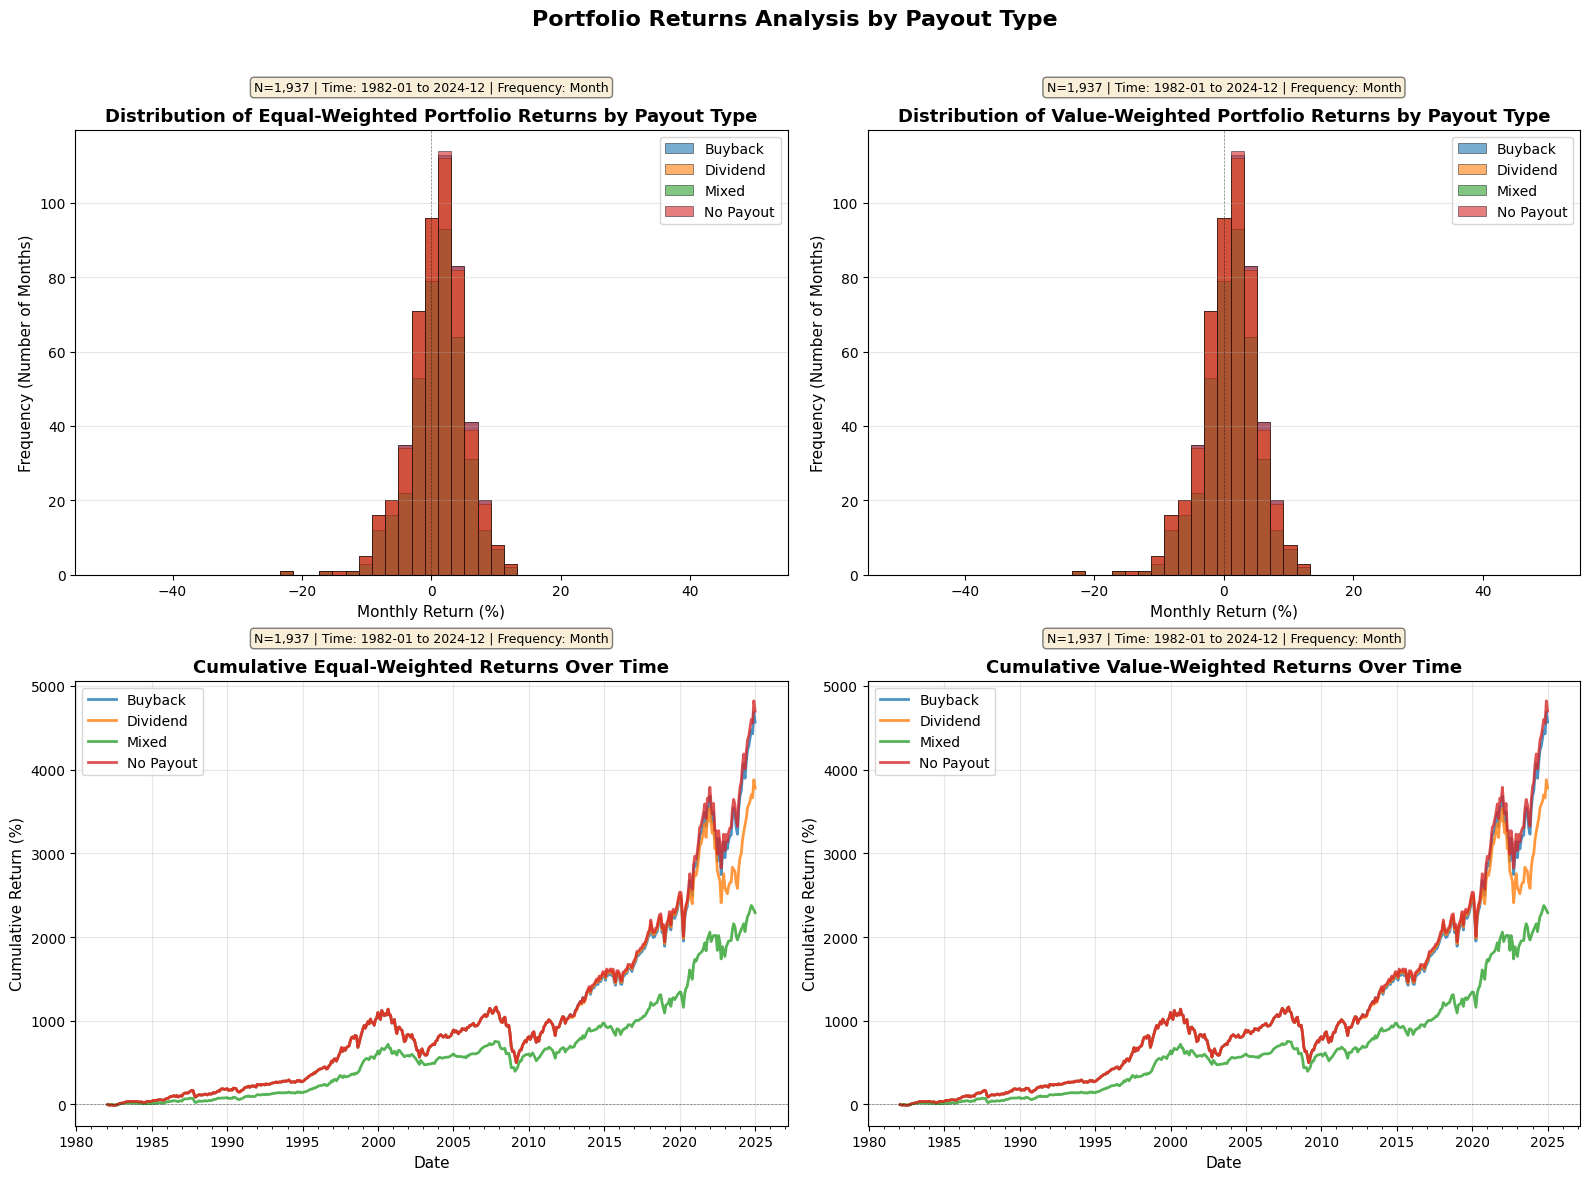


Function 'calculate_portfolio_returns' is now available for use!

Example usage:
  # By payout type:
  returns_by_payout = calculate_portfolio_returns(final_data, groupby_cols=['payout_type'])

  # By industry within payout type:
  returns_by_industry = calculate_portfolio_returns(
      final_data[final_data['payout_type']=='buyback'],
      groupby_cols=['industry']
  )

  # By size quintiles:
  final_data['size_quintile'] = pd.qcut(final_data['market_cap'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
  returns_by_size = calculate_portfolio_returns(final_data, groupby_cols=['size_quintile'])

  # By ROA terciles:
  final_data['roa_tercile'] = pd.qcut(final_data['roa'], 3, labels=['Low','Mid','High'])
  returns_by_roa = calculate_portfolio_returns(final_data, groupby_cols=['roa_tercile'])


In [ ]:
"""
Step 9: Flexible Portfolio Return Analysis Function
Function to calculate equal-weighted and value-weighted portfolio returns.
Can be used to analyze returns by payout type, industry, size, ROA, etc.
"""

def calculate_portfolio_returns(df, groupby_cols=None, min_firms=5, 
                                return_col="sprtrn", market_cap_col="market_cap",
                                date_col="month", include_no_payout=True):
    """
    Calculate equal-weighted and value-weighted portfolio returns.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with return and market cap data
    groupby_cols : list or None
        Columns to group by (e.g., ["payout_type"], ["payout_type", "industry"], etc.)
        If None, calculates overall portfolio returns
    min_firms : int
        Minimum number of firms required per group per month (default: 5)
    return_col : str
        Column name for stock returns (default: "sprtrn")
    market_cap_col : str
        Column name for market capitalization (default: "market_cap")
    date_col : str
        Column name for date/month (default: "month")
    include_no_payout : bool
        If True, include "no_payout" observations. If False, exclude them (default: True)
    
    Returns:
    --------
    DataFrame with columns:
        - date_col: Time period
        - groupby_cols: Grouping columns (if any)
        - ew_return: Equal-weighted portfolio return
        - vw_return: Value-weighted portfolio return
        - n_firms: Number of firms in portfolio
    """
    
    # Ensure required columns exist
    required_cols = [return_col, market_cap_col, date_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Filter out invalid data
    df_clean = df[
        df[return_col].notna() & 
        df[market_cap_col].notna() & 
        (df[market_cap_col] > 0)
    ].copy()
    
    # Filter out no_payout if include_no_payout is False
    if not include_no_payout and "payout_type" in df_clean.columns:
        df_clean = df_clean[df_clean["payout_type"] != "no_payout"].copy()
    
    if len(df_clean) == 0:
        raise ValueError("No valid data after filtering")
    
    # Determine grouping structure
    if groupby_cols is None:
        group_cols = [date_col]
        df_clean["_group"] = "Overall"
    else:
        group_cols = [date_col] + groupby_cols
        # Create a label for display
        df_clean["_group"] = df_clean[groupby_cols].apply(
            lambda x: " | ".join([str(val) for val in x]), axis=1
        )
    
    # Calculate portfolio returns by month and group
    results = []
    
    for name, group in df_clean.groupby(group_cols):
        if isinstance(name, tuple):
            month = name[0]
            group_vals = name[1:]
        else:
            month = name
            group_vals = ()
        
        # Filter by minimum firms
        if len(group) < min_firms:
            continue
        
        # Equal-weighted return (simple average)
        ew_return = group[return_col].mean()
        
        # Value-weighted return
        weights = group[market_cap_col]
        vw_return = (group[return_col] * weights).sum() / weights.sum()
        
        # Create result dictionary
        result = {
            date_col: month,
            "ew_return": ew_return,
            "vw_return": vw_return,
            "n_firms": len(group)
        }
        
        # Add groupby columns
        if groupby_cols:
            for idx, col in enumerate(groupby_cols):
                result[col] = group_vals[idx]
        
        results.append(result)
    
    result_df = pd.DataFrame(results)
    
    # Sort by date and group columns
    if groupby_cols:
        sort_cols = [date_col] + groupby_cols
    else:
        sort_cols = [date_col]
    result_df = result_df.sort_values(sort_cols).reset_index(drop=True)
    
    return result_df


# ============================================================================
# Example Usage: Compare Returns by Payout Type
# ============================================================================

print("=" * 80)
print("EXAMPLE 1: PORTFOLIO RETURNS BY PAYOUT TYPE")
print("=" * 80)

returns_by_payout = calculate_portfolio_returns(
    final_data,
    groupby_cols=["payout_type"],
    min_firms=5
)

print(f"\nCalculated returns for {len(returns_by_payout)} month-payout type combinations")
print(f"\nSample results:")
display(returns_by_payout.head(10))

# Summary statistics
print("\n" + "=" * 80)
print("Average Returns by Payout Type (Equal-Weighted)")
print("=" * 80)
ew_summary = returns_by_payout.groupby("payout_type").agg({
    "ew_return": "mean",
    "n_firms": "mean"
}).round(4) * 100  # Convert to percentage
ew_summary = ew_summary.rename(columns={
    "ew_return": "Avg EW Return (%)",
    "n_firms": "Avg Firms"
})
ew_summary = ew_summary.reindex(payout_order)
display(ew_summary)

print("\nAverage Returns by Payout Type (Value-Weighted)")
print("=" * 80)
vw_summary = returns_by_payout.groupby("payout_type").agg({
    "vw_return": "mean",
    "n_firms": "mean"
}).round(4) * 100  # Convert to percentage
vw_summary = vw_summary.rename(columns={
    "vw_return": "Avg VW Return (%)",
    "n_firms": "Avg Firms"
})
vw_summary = vw_summary.reindex(payout_order)
display(vw_summary)

# ============================================================================
# Visualizations: Portfolio Returns Over Time
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure payout_order is defined (fallback if not defined earlier)
if 'payout_order' not in globals():
    payout_order = sorted(returns_by_payout['payout_type'].unique())

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate statistics for subtitle
n_obs = len(returns_by_payout)
min_date = returns_by_payout['month'].min()
max_date = returns_by_payout['month'].max()
obs_freq = "Month"
time_range = f"{min_date.strftime('%Y-%m')} to {max_date.strftime('%Y-%m')}"

# Add title and subtitle
fig.suptitle('Portfolio Returns Analysis by Payout Type', fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.965, f'N={n_obs:,} | Time: {time_range} | Frequency: {obs_freq}',
         ha='center', va='top', fontsize=10, style='italic')

# Define colors for each payout type
colors = {
    'buyback': '#1f77b4',
    'dividend': '#ff7f0e',
    'mixed': '#2ca02c',
    'no_payout': '#d62728'
}

# Ensure month is datetime if it's not already
returns_by_payout['month'] = pd.to_datetime(returns_by_payout['month'])



# Plot 1: Equal-Weighted Returns Distribution (Histograms)
ax1 = axes[0, 0]
# Collect all returns for histogram
all_returns = []
labels = []
for ptype in payout_order:
    ptype_data = returns_by_payout[returns_by_payout['payout_type'] == ptype]
    if len(ptype_data) > 0:
        returns = ptype_data['ew_return'] * 100  # Convert to percentage
        all_returns.append(returns)
        labels.append(ptype.replace('_', ' ').title())

# Create histograms with transparency for overlay
bins = np.linspace(-50, 50, 50)  # Define bins from -50% to +50%
for i, (returns, label) in enumerate(zip(all_returns, labels)):
    ptype_key = payout_order[i]
    ax1.hist(returns, bins=bins, 
            label=label,
            color=colors.get(ptype_key, '#808080'),
            alpha=0.6,
            edgecolor='black',
            linewidth=0.5)



ax1.set_ylabel('Frequency (Number of Months)', fontsize=11)
ax1.set_xlabel('Monthly Return (%)', fontsize=11)
ax1.set_title('Distribution of Equal-Weighted Portfolio Returns by Payout Type', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='best', frameon=True)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Plot 2: Value-Weighted Returns Distribution (Histograms)
ax2 = axes[0, 1]
# Collect all returns for histogram
all_returns_vw = []
labels_vw = []
for ptype in payout_order:
    ptype_data = returns_by_payout[returns_by_payout['payout_type'] == ptype]
    if len(ptype_data) > 0:
        returns = ptype_data['vw_return'] * 100  # Convert to percentage
        all_returns_vw.append(returns)
        labels_vw.append(ptype.replace('_', ' ').title())

# Create histograms with transparency for overlay
bins = np.linspace(-50, 50, 50)  # Define bins from -50% to +50%
for i, (returns, label) in enumerate(zip(all_returns_vw, labels_vw)):
    ptype_key = payout_order[i]
    ax2.hist(returns, bins=bins, 
            label=label,
            color=colors.get(ptype_key, '#808080'),
            alpha=0.6,
            edgecolor='black',
            linewidth=0.5)



ax2.set_ylabel('Frequency (Number of Months)', fontsize=11)
ax2.set_xlabel('Monthly Return (%)', fontsize=11)
ax2.set_title('Distribution of Value-Weighted Portfolio Returns by Payout Type', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='best', frameon=True)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Plot 3: Cumulative Returns (Equal-Weighted)
ax3 = axes[1, 0]
for ptype in payout_order:
    ptype_data = returns_by_payout[returns_by_payout['payout_type'] == ptype].sort_values('month')
    if len(ptype_data) > 0:
        # Calculate cumulative returns: (1 + r1) * (1 + r2) * ... - 1
        cumulative = (1 + ptype_data['ew_return']).cumprod() - 1
        ax3.plot(ptype_data['month'], cumulative * 100,
                label=ptype.replace('_', ' ').title(),
                color=colors.get(ptype, '#808080'),
                linewidth=2,
                alpha=0.8)



ax3.set_ylabel('Cumulative Return (%)', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.set_title('Cumulative Equal-Weighted Returns Over Time', fontsize=13, fontweight='bold')
ax3.legend(loc='best', frameon=True)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Format x-axis
ax3.xaxis.set_major_locator(mdates.YearLocator(5))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_minor_locator(mdates.YearLocator())

# Plot 4: Cumulative Returns (Value-Weighted)
ax4 = axes[1, 1]
for ptype in payout_order:
    ptype_data = returns_by_payout[returns_by_payout['payout_type'] == ptype].sort_values('month')
    if len(ptype_data) > 0:
        # Calculate cumulative returns
        cumulative = (1 + ptype_data['vw_return']).cumprod() - 1
        ax4.plot(ptype_data['month'], cumulative * 100,
                label=ptype.replace('_', ' ').title(),
                color=colors.get(ptype, '#808080'),
                linewidth=2,
                alpha=0.8)



ax4.set_ylabel('Cumulative Return (%)', fontsize=11)
ax4.set_xlabel('Date', fontsize=11)
ax4.set_title('Cumulative Value-Weighted Returns Over Time', fontsize=13, fontweight='bold')
ax4.legend(loc='best', frameon=True)
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Format x-axis
ax4.xaxis.set_major_locator(mdates.YearLocator(5))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_minor_locator(mdates.YearLocator())

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print("\n" + "=" * 80)
print("Function 'calculate_portfolio_returns' is now available for use!")
print("=" * 80)
print("\nExample usage:")
print("  # By payout type:")
print("  returns_by_payout = calculate_portfolio_returns(final_data, groupby_cols=['payout_type'])")
print("\n  # By industry within payout type:")
print("  returns_by_industry = calculate_portfolio_returns(")
print("      final_data[final_data['payout_type']=='buyback'],")
print("      groupby_cols=['industry']")
print("  )")
print("\n  # By size quintiles:")
print("  final_data['size_quintile'] = pd.qcut(final_data['market_cap'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])")
print("  returns_by_size = calculate_portfolio_returns(final_data, groupby_cols=['size_quintile'])")
print("\n  # By ROA terciles:")
print("  final_data['roa_tercile'] = pd.qcut(final_data['roa'], 3, labels=['Low','Mid','High'])")
print("  returns_by_roa = calculate_portfolio_returns(final_data, groupby_cols=['roa_tercile'])")



STEP 10: SPECIFIC PORTFOLIO RETURN ANALYSIS EXAMPLES

EXAMPLE 1: RETURNS BY INDUSTRY FOR DIVIDEND AND BUYBACK FIRMS

Calculated returns for 3654 combinations

AVERAGE RETURNS BY INDUSTRY FOR DIVIDEND AND BUYBACK FIRMS


payout_type,buyback,dividend
industry,,
Retail Trade,0.41,0.51
Mining,1.24,0.18
Services,0.63,0.87
Manufacturing,0.77,0.77
"Finance, Insurance, And Real Estate",0.65,0.94
"Transportation, Communications, Electric, Gas, And Sanitary Services",1.01,0.60
Wholesale Trade,0.86,0.91
Construction,0.70,1.80
Public Administration,1.03,2.14


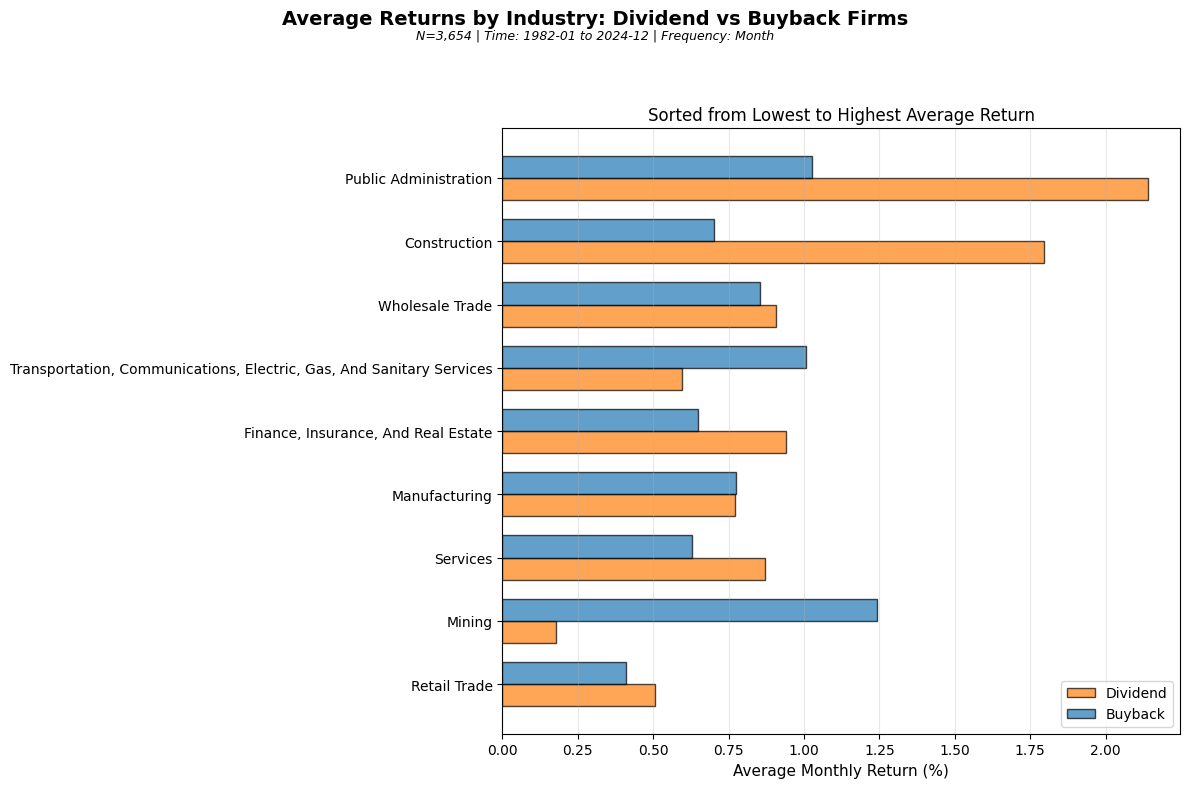



EXAMPLE 2: RETURNS BY SIZE QUARTILES WITH MARKET CAP OVER TIME

Calculated returns for 1793 month-industry combinations

Average Returns by Industry (Equal-Weighted):


,Avg EW Return (%),Avg Firms
industry,,
Mining,1.24,2219.15
Public Administration,1.03,509.38
"Transportation, Communications, Electric, Gas, And Sanitary Services",1.01,2417.39
Wholesale Trade,0.86,896.58
Manufacturing,0.77,3964.18
Construction,0.70,1001.72
"Finance, Insurance, And Real Estate",0.65,3356.59
Services,0.63,2743.87
Retail Trade,0.41,1362.70


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/1242876741.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_clean.groupby(group_cols):



Calculated returns for 2064 combinations

AVERAGE RETURNS BY SIZE QUARTILE


,size_quartile,ew_return,Avg EW Return (%)
0,Q1 (0-25%),0.01,0.85
1,Q2 (25-50%),0.01,0.85
2,Q3 (50-75%),0.01,0.85
3,Q4 (75-100%),0.01,0.85


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/3453118555.py:199: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  market_cap_over_time = yearend_data_size.groupby(['year', 'size_quartile'])['market_cap'].mean().reset_index()


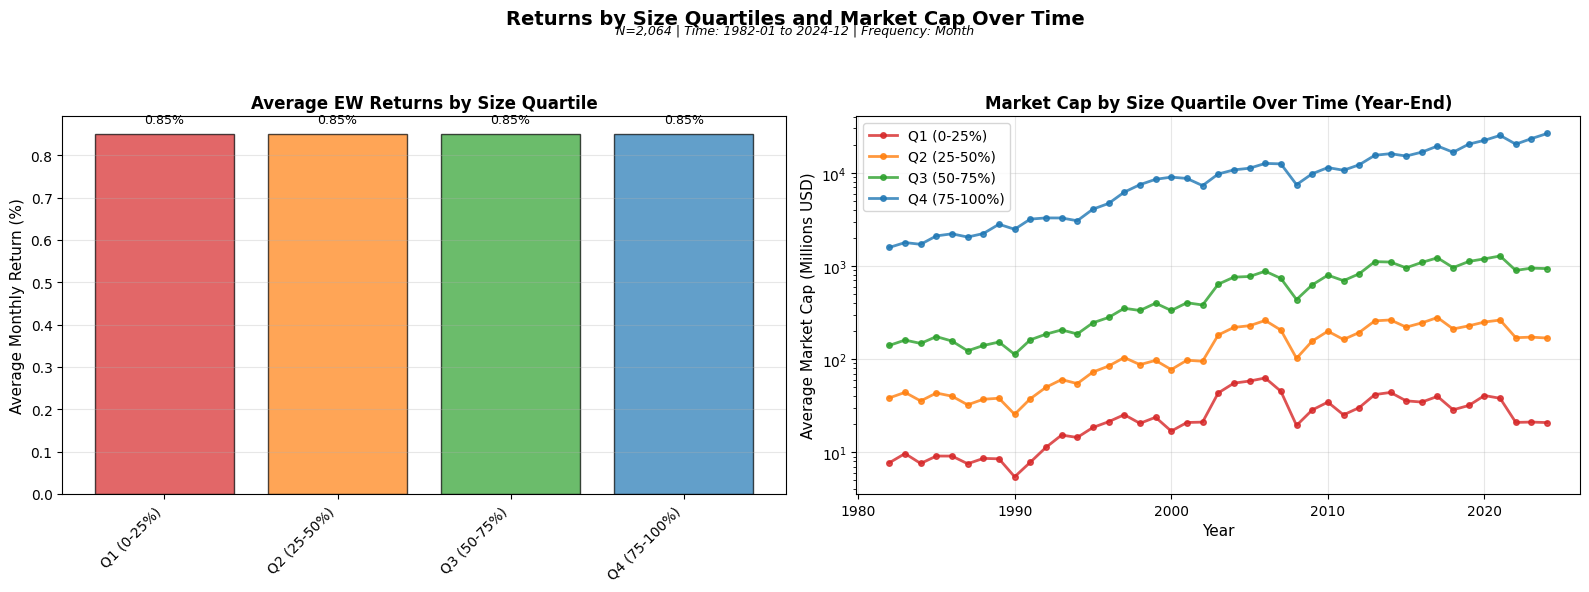


SIZE QUARTILE COMPARISON: BUYBACK VS DIVIDEND FIRMS


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/1242876741.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_clean.groupby(group_cols):



Calculated returns for 2584 combinations

Average Returns by Size Quartile: Buyback vs Dividend


payout_type,buyback,dividend
size_quartile,,
Q1 (0-25%),0.63,0.46
Q2 (25-50%),0.60,0.70
Q3 (50-75%),0.80,0.76
Q4 (75-100%),0.67,0.76


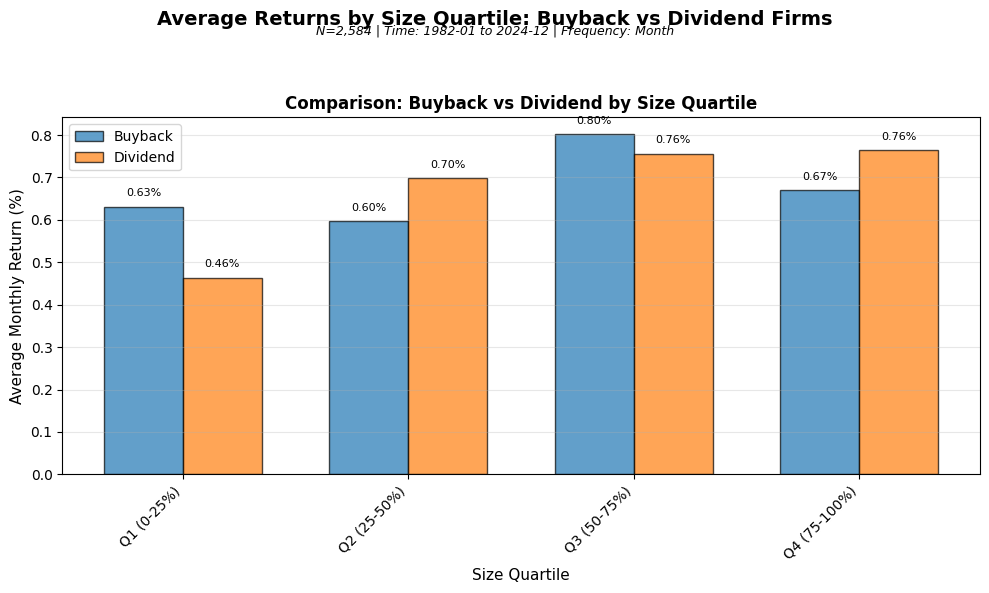



EXAMPLE 3: RETURNS BY ROA CATEGORIES WITH CUTOFFS OVER TIME


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/1242876741.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_clean.groupby(group_cols):



Calculated returns for 2386 month-size quintile combinations

Average Returns by Size Quintile (Equal-Weighted):


,Avg EW Return (%),Avg Firms
size_quintile,,
Q1 (Smallest),0.77,14439.81
Q2,0.82,12173.90
Q3,0.85,11874.76
Q4,0.88,11942.38
Q5 (Largest),0.80,14013.79



EXAMPLE 4: RETURNS BY ROA TERCILES


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/3453118555.py:376: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_data_with_roa['roa_category'] = final_data_with_roa.groupby('month', group_keys=False).apply(classify_roa_by_quartiles).reset_index(level=0, drop=True)
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/1242876741.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_clean.groupby(group_cols):



Calculated returns for 1925 combinations

AVERAGE RETURNS BY ROA CATEGORY


,roa_category,ew_return,Avg EW Return (%)
2,Very Negative,0.01,0.84
0,Negative,0.01,0.82
1,Positive,0.01,0.89
3,Very Positive,0.01,0.70



ROA CATEGORY CUTOFFS OVER TIME (Year-End)


,year,Very Negative Max,Negative Max,Positive Max,Very Positive Min
0,1982,0.0011,0.0299,0.0646,0.0646
1,1983,0.0026,0.0366,0.0715,0.0715
2,1984,0.0045,0.0394,0.0772,0.0772
3,1985,-0.0117,0.0297,0.0651,0.0651
4,1986,-0.0209,0.0248,0.0628,0.0628
5,1987,-0.0131,0.0299,0.0655,0.0655
6,1988,-0.0062,0.0277,0.0679,0.0679
7,1989,-0.0168,0.0235,0.0643,0.0643
8,1990,-0.0189,0.0200,0.0577,0.0577
9,1991,-0.0255,0.0160,0.0533,0.0533


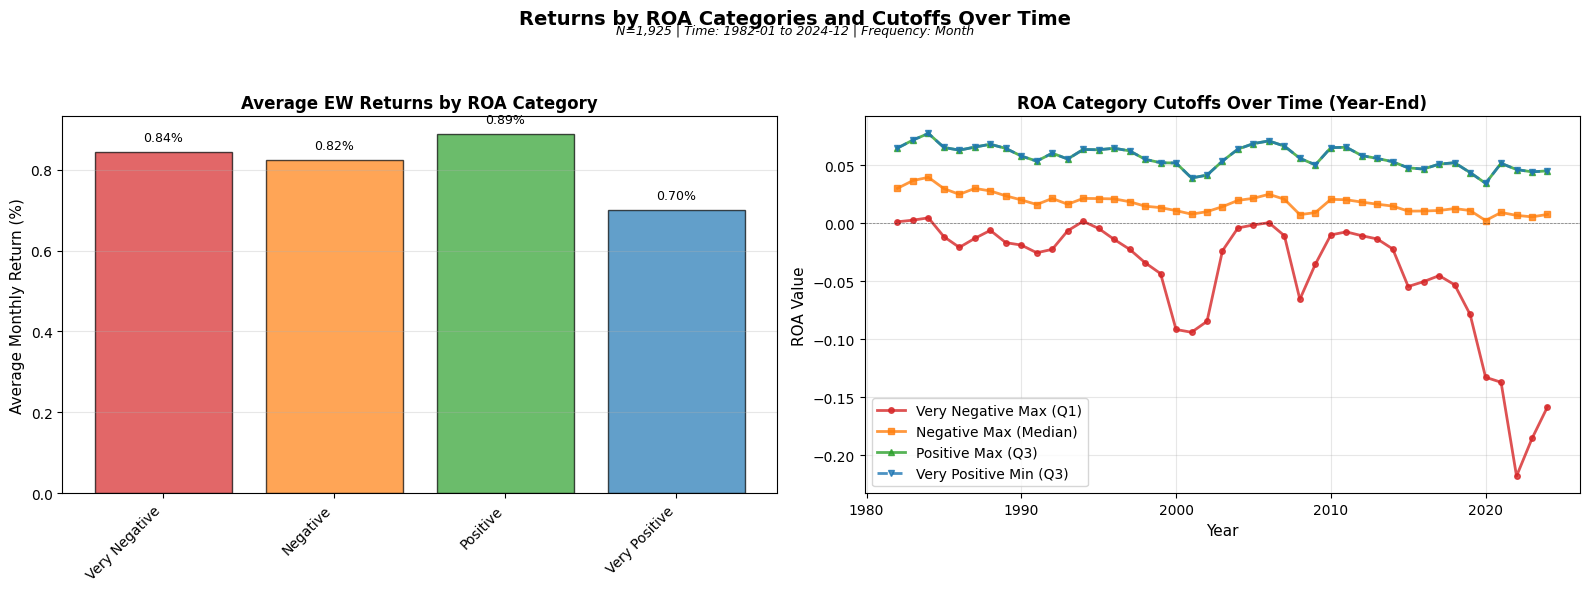


ROA CATEGORY COMPARISON: BUYBACK VS DIVIDEND FIRMS


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/1242876741.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_clean.groupby(group_cols):



Calculated returns for 2142 combinations

Average Returns by ROA Category: Buyback vs Dividend


payout_type,buyback,dividend
roa_category,,
Very Negative,0.47,0.92
Negative,0.64,0.69
Positive,0.54,0.64
Very Positive,0.69,0.69


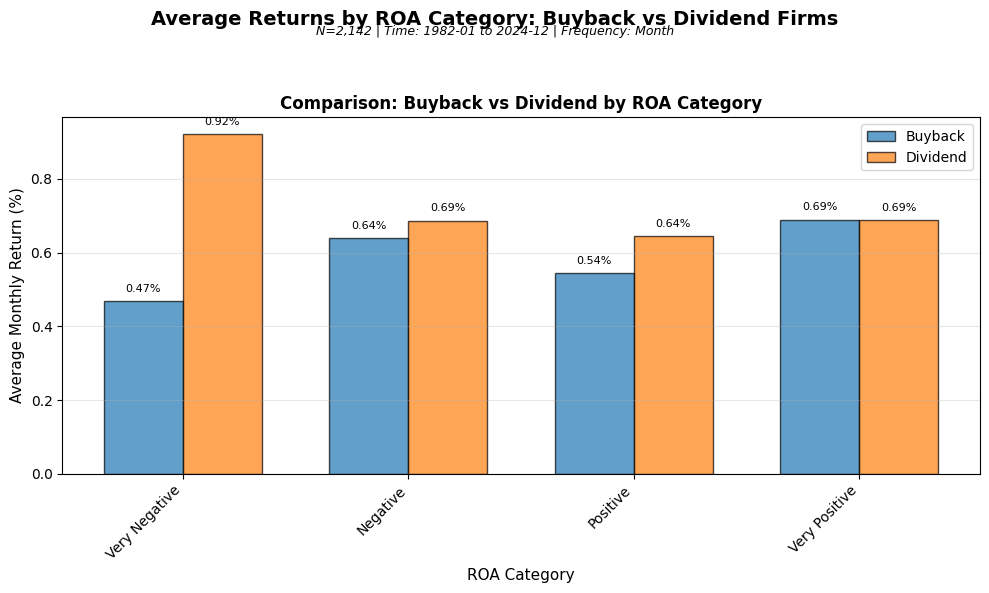



EXAMPLE 4: TOP 10 COMBINATIONS FROM EXAMPLES 1, 2, AND 3

Top 10 combinations across all categories:


,Combination,Category,payout_type,Avg EW Return (%)
9,Public Administration - dividend,Industry,dividend,2.14
1,Construction - dividend,Industry,dividend,1.80
6,Mining - buyback,Industry,buyback,1.24
8,Public Administration - buyback,Industry,buyback,1.03
14,"Transportation, Communications, Electric, Gas,...",Industry,buyback,1.01
3,"Finance, Insurance, And Real Estate - dividend",Industry,dividend,0.94
31,Very Negative - dividend,ROA Category,dividend,0.92
17,Wholesale Trade - dividend,Industry,dividend,0.91
13,Services - dividend,Industry,dividend,0.87
16,Wholesale Trade - buyback,Industry,buyback,0.86


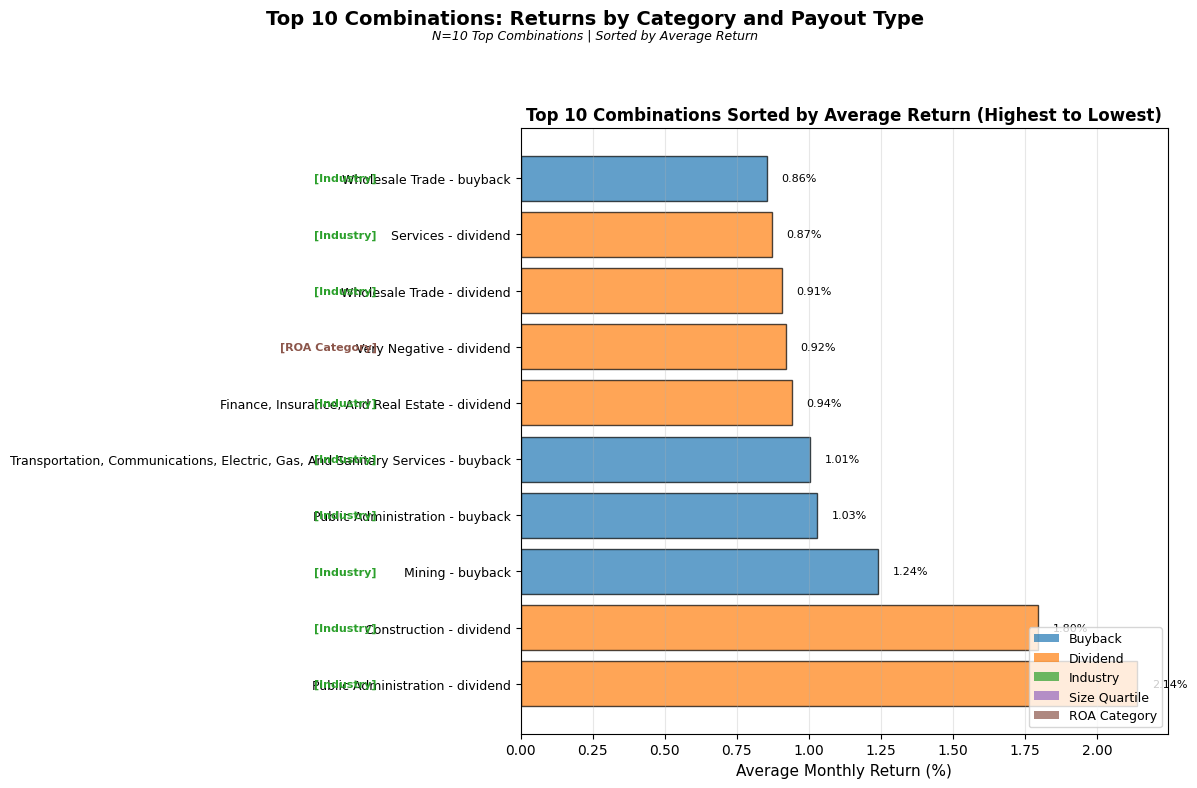


All example analyses complete!


In [52]:
"""
Step 10: Specific Portfolio Return Analysis Examples
Focus on 4 specific examples:
1. Returns by Industry for Dividend and Buyback firms
2. Returns by Size Quartiles with Market Cap over time
3. Returns by ROA Categories with cutoffs over time
"""

print("\n" + "=" * 80)
print("STEP 10: SPECIFIC PORTFOLIO RETURN ANALYSIS EXAMPLES")
print("=" * 80)

# ============================================================================
# Example 1: Returns by Industry for Dividend and Buyback Firms
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE 1: RETURNS BY INDUSTRY FOR DIVIDEND AND BUYBACK FIRMS")
print("=" * 80)

# Filter for dividend and buyback firms only
dividend_buyback_data = final_data[final_data['payout_type'].isin(['dividend', 'buyback'])].copy()

# Calculate returns by industry for each payout type
returns_by_industry_payout = calculate_portfolio_returns(
    dividend_buyback_data,
    groupby_cols=['payout_type', 'industry'],
    min_firms=3,
    include_no_payout=False
)

print(f"\nCalculated returns for {len(returns_by_industry_payout)} combinations")

# Create summary: Average returns by industry and payout type
industry_payout_summary = returns_by_industry_payout.groupby(['payout_type', 'industry'])['ew_return'].mean().reset_index()
industry_payout_summary['Avg EW Return (%)'] = industry_payout_summary['ew_return'] * 100

# Pivot for easier comparison
industry_pivot = industry_payout_summary.pivot(index='industry', columns='payout_type', values='Avg EW Return (%)')

# Sort by average of both payout types (or by buyback if dividend missing)
industry_pivot['avg'] = industry_pivot.mean(axis=1)
industry_pivot = industry_pivot.sort_values('avg', ascending=True)  # Lowest to highest
industry_pivot = industry_pivot.drop('avg', axis=1)

# Display the dataframe
print("\n" + "=" * 80)
print("AVERAGE RETURNS BY INDUSTRY FOR DIVIDEND AND BUYBACK FIRMS")
print("=" * 80)
display(industry_pivot.round(2))

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, max(8, len(industry_pivot) * 0.3)))

# Add title and subtitle
n_obs = len(returns_by_industry_payout)
min_date = returns_by_industry_payout['month'].min() if 'month' in returns_by_industry_payout.columns else None
max_date = returns_by_industry_payout['month'].max() if 'month' in returns_by_industry_payout.columns else None
time_range = f"{min_date.strftime('%Y-%m')} to {max_date.strftime('%Y-%m')}" if min_date and max_date else "N/A"

fig.suptitle('Average Returns by Industry: Dividend vs Buyback Firms', 
             fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.955, f'N={n_obs:,} | Time: {time_range} | Frequency: Month',
         ha='center', va='top', fontsize=9, style='italic')

# Get data for plotting
industries = industry_pivot.index
x_pos = np.arange(len(industries))
width = 0.35

# Plot bars
if 'dividend' in industry_pivot.columns:
    dividend_vals = industry_pivot['dividend'].fillna(0)
    ax.barh(x_pos - width/2, dividend_vals, width, 
           label='Dividend', color='#ff7f0e', alpha=0.7, edgecolor='black')

if 'buyback' in industry_pivot.columns:
    buyback_vals = industry_pivot['buyback'].fillna(0)
    ax.barh(x_pos + width/2, buyback_vals, width, 
           label='Buyback', color='#1f77b4', alpha=0.7, edgecolor='black')

ax.set_yticks(x_pos)
ax.set_yticklabels(industries)
ax.set_xlabel('Average Monthly Return (%)', fontsize=11)
ax.set_title('Sorted from Lowest to Highest Average Return', fontsize=12)
ax.legend(loc='best', frameon=True)
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("\n" + "=" * 80)

# ============================================================================
# Example 2: Returns by Size Quartiles with Market Cap over Time
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE 2: RETURNS BY SIZE QUARTILES WITH MARKET CAP OVER TIME")
print("=" * 80)

buyback_data = final_data[final_data["payout_type"] == "buyback"].copy()
returns_by_industry = calculate_portfolio_returns(
    buyback_data,
    groupby_cols=["industry"],
    min_firms=3
)

print(f"\nCalculated returns for {len(returns_by_industry)} month-industry combinations")
print("\nAverage Returns by Industry (Equal-Weighted):")
industry_summary = returns_by_industry.groupby("industry").agg({
    "ew_return": "mean",
    "n_firms": "mean"
}).round(4) * 100  # Convert to percentage
industry_summary = industry_summary.rename(columns={
    "ew_return": "Avg EW Return (%)",
    "n_firms": "Avg Firms"
})
industry_summary = industry_summary.sort_values("Avg EW Return (%)", ascending=False)
display(industry_summary.head(10))

# Create size quartiles (0-25, 25-50, 50-75, 75-100%)
# Only use observations with valid market cap
final_data_with_size = final_data[final_data['market_cap'].notna()].copy()

# Create quartiles within each month to account for market cap changes over time
final_data_with_size['size_quartile'] = final_data_with_size.groupby('month')['market_cap'].transform(
    lambda x: pd.qcut(x, q=4, labels=['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)'], duplicates='drop')
)

# Calculate returns by size quartile
returns_by_size_quartile = calculate_portfolio_returns(
    final_data_with_size,
    groupby_cols=['size_quartile'],
    min_firms=5,
    include_no_payout=True
)

print(f"\nCalculated returns for {len(returns_by_size_quartile)} combinations")

# Create summary: Average returns by size quartile
size_summary = returns_by_size_quartile.groupby('size_quartile')['ew_return'].mean().reset_index()
size_summary['Avg EW Return (%)'] = size_summary['ew_return'] * 100

# Sort by quartile order
quartile_order = ['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)']
size_summary['quartile_num'] = size_summary['size_quartile'].apply(lambda x: quartile_order.index(x) if x in quartile_order else 99)
size_summary = size_summary.sort_values('quartile_num').drop('quartile_num', axis=1)

# Display the dataframe
print("\n" + "=" * 80)
print("AVERAGE RETURNS BY SIZE QUARTILE")
print("=" * 80)
display(size_summary.round(2))

# Create bar chart for returns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Add title and subtitle
n_obs_size = len(returns_by_size_quartile)
min_date_size = returns_by_size_quartile['month'].min() if 'month' in returns_by_size_quartile.columns else None
max_date_size = returns_by_size_quartile['month'].max() if 'month' in returns_by_size_quartile.columns else None
time_range_size = f"{min_date_size.strftime('%Y-%m')} to {max_date_size.strftime('%Y-%m')}" if min_date_size and max_date_size else "N/A"

fig.suptitle('Returns by Size Quartiles and Market Cap Over Time', 
             fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.955, f'N={n_obs_size:,} | Time: {time_range_size} | Frequency: Month',
         ha='center', va='top', fontsize=9, style='italic')

# Plot 1: Bar chart of average returns by quartile
ax1 = axes[0]
bars = ax1.bar(range(len(size_summary)), size_summary['Avg EW Return (%)'].values,
               color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'][:len(size_summary)],
               alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(size_summary)))
ax1.set_xticklabels(size_summary['size_quartile'], rotation=45, ha='right')
ax1.set_ylabel('Average Monthly Return (%)', fontsize=11)
ax1.set_title('Average EW Returns by Size Quartile', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add value labels
for i, (_, row) in enumerate(size_summary.iterrows()):
    val = row['Avg EW Return (%)']
    ax1.text(i, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Plot 2: Market cap by quartile over time (using year-end values)
ax2 = axes[1]
final_data_with_size['month'] = pd.to_datetime(final_data_with_size['month'])
final_data_with_size['year'] = final_data_with_size['month'].dt.year
final_data_with_size['month_num'] = final_data_with_size['month'].dt.month

# Filter to year-end (December)
yearend_data_size = final_data_with_size[final_data_with_size['month_num'] == 12].copy()

# Calculate average market cap by quartile and year
market_cap_over_time = yearend_data_size.groupby(['year', 'size_quartile'])['market_cap'].mean().reset_index()
market_cap_over_time['market_cap_millions'] = market_cap_over_time['market_cap'] / 1_000_000  # Convert to millions

# Plot each quartile
colors_quartile = {'Q1 (0-25%)': '#d62728', 'Q2 (25-50%)': '#ff7f0e', 
                   'Q3 (50-75%)': '#2ca02c', 'Q4 (75-100%)': '#1f77b4'}
for quartile in quartile_order:
    if quartile in market_cap_over_time['size_quartile'].values:
        quartile_data = market_cap_over_time[market_cap_over_time['size_quartile'] == quartile].sort_values('year')
        ax2.plot(quartile_data['year'], quartile_data['market_cap_millions'],
                label=quartile, color=colors_quartile.get(quartile, '#808080'),
                linewidth=2, marker='o', markersize=4, alpha=0.8)

ax2.set_ylabel('Average Market Cap (Millions USD)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title('Market Cap by Size Quartile Over Time (Year-End)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', frameon=True)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')  # Use log scale for better visualization

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Additional graph: Buyback vs Dividend by Size Quartile
print("\n" + "=" * 80)
print("SIZE QUARTILE COMPARISON: BUYBACK VS DIVIDEND FIRMS")
print("=" * 80)

# Calculate returns by size quartile AND payout type (buyback vs dividend)
size_payout_data = final_data_with_size[
    final_data_with_size['payout_type'].isin(['buyback', 'dividend'])
].copy()

returns_by_size_payout = calculate_portfolio_returns(
    size_payout_data,
    groupby_cols=['size_quartile', 'payout_type'],
    min_firms=5,
    include_no_payout=False
)

print(f"\nCalculated returns for {len(returns_by_size_payout)} combinations")

# Create summary
size_payout_summary = returns_by_size_payout.groupby(['size_quartile', 'payout_type'])['ew_return'].mean().reset_index()
size_payout_summary['Avg EW Return (%)'] = size_payout_summary['ew_return'] * 100

# Pivot for comparison
size_payout_pivot = size_payout_summary.pivot(index='size_quartile', columns='payout_type', values='Avg EW Return (%)')

# Sort by quartile order
quartile_order = ['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)']
size_payout_pivot = size_payout_pivot.reindex([q for q in quartile_order if q in size_payout_pivot.index])

print("\nAverage Returns by Size Quartile: Buyback vs Dividend")
display(size_payout_pivot.round(2))

# Create vertical bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Add title and subtitle
n_obs_sp = len(returns_by_size_payout)
min_date_sp = returns_by_size_payout['month'].min() if 'month' in returns_by_size_payout.columns else None
max_date_sp = returns_by_size_payout['month'].max() if 'month' in returns_by_size_payout.columns else None
time_range_sp = f"{min_date_sp.strftime('%Y-%m')} to {max_date_sp.strftime('%Y-%m')}" if min_date_sp and max_date_sp else "N/A"

fig.suptitle('Average Returns by Size Quartile: Buyback vs Dividend Firms', 
             fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.955, f'N={n_obs_sp:,} | Time: {time_range_sp} | Frequency: Month',
         ha='center', va='top', fontsize=9, style='italic')

x = np.arange(len(size_payout_pivot))
width = 0.35

# Plot bars
if 'buyback' in size_payout_pivot.columns:
    buyback_vals = size_payout_pivot['buyback'].fillna(0)
    ax.bar(x - width/2, buyback_vals, width, 
           label='Buyback', color='#1f77b4', alpha=0.7, edgecolor='black')

if 'dividend' in size_payout_pivot.columns:
    dividend_vals = size_payout_pivot['dividend'].fillna(0)
    ax.bar(x + width/2, dividend_vals, width, 
           label='Dividend', color='#ff7f0e', alpha=0.7, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(size_payout_pivot.index, rotation=45, ha='right')
ax.set_ylabel('Average Monthly Return (%)', fontsize=11)
ax.set_xlabel('Size Quartile', fontsize=11)
ax.set_title('Comparison: Buyback vs Dividend by Size Quartile', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add value labels
for i, quartile in enumerate(size_payout_pivot.index):
    if 'buyback' in size_payout_pivot.columns and not pd.isna(size_payout_pivot.loc[quartile, 'buyback']):
        val = size_payout_pivot.loc[quartile, 'buyback']
        ax.text(i - width/2, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    if 'dividend' in size_payout_pivot.columns and not pd.isna(size_payout_pivot.loc[quartile, 'dividend']):
        val = size_payout_pivot.loc[quartile, 'dividend']
        ax.text(i + width/2, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("\n" + "=" * 80)

# ============================================================================
# Example 3: Returns by ROA Categories with Cutoffs Over Time
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE 3: RETURNS BY ROA CATEGORIES WITH CUTOFFS OVER TIME")
print("=" * 80)

# Create size quintiles
final_data_with_size = final_data.copy()
final_data_with_size["size_quintile"] = pd.qcut(
    final_data_with_size["market_cap"], 
    5, 
    labels=["Q1 (Smallest)", "Q2", "Q3", "Q4", "Q5 (Largest)"],
    duplicates="drop"
)

returns_by_size = calculate_portfolio_returns(
    final_data_with_size,
    groupby_cols=["size_quintile"],
    min_firms=5
)

print(f"\nCalculated returns for {len(returns_by_size)} month-size quintile combinations")
print("\nAverage Returns by Size Quintile (Equal-Weighted):")
size_summary = returns_by_size.groupby("size_quintile").agg({
    "ew_return": "mean",
    "n_firms": "mean"
}).round(4) * 100
size_summary = size_summary.rename(columns={
    "ew_return": "Avg EW Return (%)",
    "n_firms": "Avg Firms"
})
display(size_summary)

# ============================================================================
# Example 4: Returns by ROA Terciles
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE 4: RETURNS BY ROA TERCILES")
print("=" * 80)

# Create ROA categories: Very Negative, Negative, Positive, Very Positive
# Cutoffs will be calculated within each month to account for changes over time
final_data_with_roa = final_data[final_data["roa"].notna()].copy()

# Calculate quartiles within each month for ROA distribution
# Then classify as: Very Negative (bottom 25%), Negative (25-50%), Positive (50-75%), Very Positive (top 25%)
def classify_roa_by_quartiles(group):
    """Classify ROA into 4 categories based on quartiles within each month"""
    try:
        quartiles = pd.qcut(group['roa'], q=4, labels=['Very Negative', 'Negative', 'Positive', 'Very Positive'], duplicates='drop')
        return quartiles
    except:
        # If not enough distinct values, use simple cutoffs
        median = group['roa'].median()
        q1 = group['roa'].quantile(0.25)
        q3 = group['roa'].quantile(0.75)
        conditions = [
            group['roa'] <= q1,
            (group['roa'] > q1) & (group['roa'] <= median),
            (group['roa'] > median) & (group['roa'] <= q3),
            group['roa'] > q3
        ]
        choices = ['Very Negative', 'Negative', 'Positive', 'Very Positive']
        return pd.Series(np.select(conditions, choices, default='Positive'), index=group.index)

final_data_with_roa['roa_category'] = final_data_with_roa.groupby('month', group_keys=False).apply(classify_roa_by_quartiles).reset_index(level=0, drop=True)

# Calculate returns by ROA category
returns_by_roa = calculate_portfolio_returns(
    final_data_with_roa,
    groupby_cols=['roa_category'],
    min_firms=5,
    include_no_payout=True
)

print(f"\nCalculated returns for {len(returns_by_roa)} combinations")

# Create summary: Average returns by ROA category
roa_summary = returns_by_roa.groupby('roa_category')['ew_return'].mean().reset_index()
roa_summary['Avg EW Return (%)'] = roa_summary['ew_return'] * 100

# Sort by category order
roa_order = ['Very Negative', 'Negative', 'Positive', 'Very Positive']
roa_summary['roa_num'] = roa_summary['roa_category'].apply(lambda x: roa_order.index(x) if x in roa_order else 99)
roa_summary = roa_summary.sort_values('roa_num').drop('roa_num', axis=1)

# Display the dataframe
print("\n" + "=" * 80)
print("AVERAGE RETURNS BY ROA CATEGORY")
print("=" * 80)
display(roa_summary.round(2))

# Calculate cutoffs over time (year-end values)
final_data_with_roa['month'] = pd.to_datetime(final_data_with_roa['month'])
final_data_with_roa['year'] = final_data_with_roa['month'].dt.year
final_data_with_roa['month_num'] = final_data_with_roa['month'].dt.month

# Filter to year-end (December) for cleaner visualization
yearend_data_roa = final_data_with_roa[final_data_with_roa['month_num'] == 12].copy()

# Calculate quartile cutoffs by year
cutoffs_by_year = []
for year in sorted(yearend_data_roa['year'].unique()):
    year_data = yearend_data_roa[yearend_data_roa['year'] == year]
    if len(year_data) > 0:
        roa_vals = year_data['roa'].dropna()
        if len(roa_vals) >= 4:
            q1 = roa_vals.quantile(0.25)
            q2 = roa_vals.quantile(0.50)  # median
            q3 = roa_vals.quantile(0.75)
            cutoffs_by_year.append({
                'year': year,
                'Very Negative Max': q1,
                'Negative Max': q2,
                'Positive Max': q3,
                'Very Positive Min': q3
            })

cutoffs_df = pd.DataFrame(cutoffs_by_year)

print("\n" + "=" * 80)
print("ROA CATEGORY CUTOFFS OVER TIME (Year-End)")
print("=" * 80)
display(cutoffs_df.round(4))

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Add title and subtitle
n_obs_roa = len(returns_by_roa)
min_date_roa = returns_by_roa['month'].min() if 'month' in returns_by_roa.columns else None
max_date_roa = returns_by_roa['month'].max() if 'month' in returns_by_roa.columns else None
time_range_roa = f"{min_date_roa.strftime('%Y-%m')} to {max_date_roa.strftime('%Y-%m')}" if min_date_roa and max_date_roa else "N/A"

fig.suptitle('Returns by ROA Categories and Cutoffs Over Time', 
             fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.955, f'N={n_obs_roa:,} | Time: {time_range_roa} | Frequency: Month',
         ha='center', va='top', fontsize=9, style='italic')

# Plot 1: Bar chart of average returns by ROA category
ax1 = axes[0]
bars = ax1.bar(range(len(roa_summary)), roa_summary['Avg EW Return (%)'].values,
               color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'][:len(roa_summary)],
               alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(roa_summary)))
ax1.set_xticklabels(roa_summary['roa_category'], rotation=45, ha='right')
ax1.set_ylabel('Average Monthly Return (%)', fontsize=11)
ax1.set_title('Average EW Returns by ROA Category', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add value labels
for i, (_, row) in enumerate(roa_summary.iterrows()):
    val = row['Avg EW Return (%)']
    ax1.text(i, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Plot 2: ROA cutoffs over time
ax2 = axes[1]
if len(cutoffs_df) > 0:
    ax2.plot(cutoffs_df['year'], cutoffs_df['Very Negative Max'],
            label='Very Negative Max (Q1)', color='#d62728', linewidth=2, marker='o', markersize=4, alpha=0.8)
    ax2.plot(cutoffs_df['year'], cutoffs_df['Negative Max'],
            label='Negative Max (Median)', color='#ff7f0e', linewidth=2, marker='s', markersize=4, alpha=0.8)
    ax2.plot(cutoffs_df['year'], cutoffs_df['Positive Max'],
            label='Positive Max (Q3)', color='#2ca02c', linewidth=2, marker='^', markersize=4, alpha=0.8)
    ax2.plot(cutoffs_df['year'], cutoffs_df['Very Positive Min'],
            label='Very Positive Min (Q3)', color='#1f77b4', linewidth=2, linestyle='--', marker='v', markersize=4, alpha=0.8)

ax2.set_ylabel('ROA Value', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_title('ROA Category Cutoffs Over Time (Year-End)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', frameon=True)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Additional graph: Buyback vs Dividend by ROA Category
print("\n" + "=" * 80)
print("ROA CATEGORY COMPARISON: BUYBACK VS DIVIDEND FIRMS")
print("=" * 80)

# Calculate returns by ROA category AND payout type (buyback vs dividend)
roa_payout_data = final_data_with_roa[
    final_data_with_roa['payout_type'].isin(['buyback', 'dividend'])
].copy()

returns_by_roa_payout = calculate_portfolio_returns(
    roa_payout_data,
    groupby_cols=['roa_category', 'payout_type'],
    min_firms=5,
    include_no_payout=False
)

print(f"\nCalculated returns for {len(returns_by_roa_payout)} combinations")

# Create summary
roa_payout_summary = returns_by_roa_payout.groupby(['roa_category', 'payout_type'])['ew_return'].mean().reset_index()
roa_payout_summary['Avg EW Return (%)'] = roa_payout_summary['ew_return'] * 100

# Pivot for comparison
roa_payout_pivot = roa_payout_summary.pivot(index='roa_category', columns='payout_type', values='Avg EW Return (%)')

# Sort by category order
roa_order = ['Very Negative', 'Negative', 'Positive', 'Very Positive']
roa_payout_pivot = roa_payout_pivot.reindex([r for r in roa_order if r in roa_payout_pivot.index])

print("\nAverage Returns by ROA Category: Buyback vs Dividend")
display(roa_payout_pivot.round(2))

# Create vertical bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Add title and subtitle
n_obs_rp = len(returns_by_roa_payout)
min_date_rp = returns_by_roa_payout['month'].min() if 'month' in returns_by_roa_payout.columns else None
max_date_rp = returns_by_roa_payout['month'].max() if 'month' in returns_by_roa_payout.columns else None
time_range_rp = f"{min_date_rp.strftime('%Y-%m')} to {max_date_rp.strftime('%Y-%m')}" if min_date_rp and max_date_rp else "N/A"

fig.suptitle('Average Returns by ROA Category: Buyback vs Dividend Firms', 
             fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.955, f'N={n_obs_rp:,} | Time: {time_range_rp} | Frequency: Month',
         ha='center', va='top', fontsize=9, style='italic')

x = np.arange(len(roa_payout_pivot))
width = 0.35

# Plot bars
if 'buyback' in roa_payout_pivot.columns:
    buyback_vals = roa_payout_pivot['buyback'].fillna(0)
    ax.bar(x - width/2, buyback_vals, width, 
           label='Buyback', color='#1f77b4', alpha=0.7, edgecolor='black')

if 'dividend' in roa_payout_pivot.columns:
    dividend_vals = roa_payout_pivot['dividend'].fillna(0)
    ax.bar(x + width/2, dividend_vals, width, 
           label='Dividend', color='#ff7f0e', alpha=0.7, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(roa_payout_pivot.index, rotation=45, ha='right')
ax.set_ylabel('Average Monthly Return (%)', fontsize=11)
ax.set_xlabel('ROA Category', fontsize=11)
ax.set_title('Comparison: Buyback vs Dividend by ROA Category', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add value labels
for i, category in enumerate(roa_payout_pivot.index):
    if 'buyback' in roa_payout_pivot.columns and not pd.isna(roa_payout_pivot.loc[category, 'buyback']):
        val = roa_payout_pivot.loc[category, 'buyback']
        ax.text(i - width/2, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    if 'dividend' in roa_payout_pivot.columns and not pd.isna(roa_payout_pivot.loc[category, 'dividend']):
        val = roa_payout_pivot.loc[category, 'dividend']
        ax.text(i + width/2, val + 0.02 if val >= 0 else val - 0.02, f'{val:.2f}%',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("\n" + "=" * 80)

# ============================================================================
# Example 4: Top 10 Combinations from Examples 1, 2, and 3
# ============================================================================

print("\n" + "=" * 80)
print("EXAMPLE 4: TOP 10 COMBINATIONS FROM EXAMPLES 1, 2, AND 3")
print("=" * 80)

# Collect top combinations from all three examples
top_combinations = []

# From Example 1: All industry-payout type combinations
if 'returns_by_industry_payout' in globals() and len(returns_by_industry_payout) > 0:
    industry_payout_all = returns_by_industry_payout.groupby(['industry', 'payout_type'])['ew_return'].mean().reset_index()
    industry_payout_all['Avg EW Return (%)'] = industry_payout_all['ew_return'] * 100
    industry_payout_all['Category'] = 'Industry'
    industry_payout_all['Combination'] = industry_payout_all['industry'] + ' - ' + industry_payout_all['payout_type']
    top_combinations.append(industry_payout_all[['Combination', 'Category', 'payout_type', 'Avg EW Return (%)']])

# From Example 2: All size quartile-payout type combinations
if 'returns_by_size_payout' in globals() and len(returns_by_size_payout) > 0:
    size_payout_all = returns_by_size_payout.groupby(['size_quartile', 'payout_type'])['ew_return'].mean().reset_index()
    size_payout_all['Avg EW Return (%)'] = size_payout_all['ew_return'] * 100
    size_payout_all['Category'] = 'Size Quartile'
    size_payout_all['Combination'] = size_payout_all['size_quartile'] + ' - ' + size_payout_all['payout_type']
    top_combinations.append(size_payout_all[['Combination', 'Category', 'payout_type', 'Avg EW Return (%)']])

# From Example 3: All ROA category-payout type combinations
if 'returns_by_roa_payout' in globals() and len(returns_by_roa_payout) > 0:
    roa_payout_all = returns_by_roa_payout.groupby(['roa_category', 'payout_type'])['ew_return'].mean().reset_index()
    roa_payout_all['Avg EW Return (%)'] = roa_payout_all['ew_return'] * 100
    roa_payout_all['Category'] = 'ROA Category'
    roa_payout_all['Combination'] = roa_payout_all['roa_category'] + ' - ' + roa_payout_all['payout_type']
    top_combinations.append(roa_payout_all[['Combination', 'Category', 'payout_type', 'Avg EW Return (%)']])

    # Combine all combinations and get top 10 overall
    if top_combinations:
        all_combinations = pd.concat(top_combinations, ignore_index=True)
        all_top = all_combinations.sort_values('Avg EW Return (%)', ascending=False).head(10)
        
        print(f"\nTop 10 combinations across all categories:")
        print("=" * 80)
        display(all_top.round(2))
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Add title and subtitle
        n_obs_all = len(all_top)
        fig.suptitle('Top 10 Combinations: Returns by Category and Payout Type', 
                     fontsize=14, fontweight='bold', y=0.98)
        fig.text(0.5, 0.955, f'N={n_obs_all} Top Combinations | Sorted by Average Return',
                 ha='center', va='top', fontsize=9, style='italic')
    
    # Create horizontal bar chart
    y_pos = np.arange(len(all_top))
    colors_list = ['#1f77b4' if pt == 'buyback' else '#ff7f0e' for pt in all_top['payout_type']]
    
    bars = ax.barh(y_pos, all_top['Avg EW Return (%)'].values,
                   color=colors_list, alpha=0.7, edgecolor='black')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_top['Combination'].values, fontsize=9)
    ax.set_xlabel('Average Monthly Return (%)', fontsize=11)
    ax.set_title('Top 10 Combinations Sorted by Average Return (Highest to Lowest)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add value labels
    for i, (idx, row) in enumerate(all_top.iterrows()):
        val = row['Avg EW Return (%)']
        ax.text(val + 0.05 if val >= 0 else val - 0.05, i, f'{val:.2f}%',
                va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    
    # Add category labels (colors for different categories)
    category_colors = {'Industry': '#2ca02c', 'Size Quartile': '#9467bd', 'ROA Category': '#8c564b'}
    for i, (idx, row) in enumerate(all_top.iterrows()):
        cat = row['Category']
        ax.text(-0.5 if all_top['Avg EW Return (%)'].min() >= 0 else all_top['Avg EW Return (%)'].min() - 1, i, 
                f"[{cat}]", va='center', ha='right', fontsize=8, 
                color=category_colors.get(cat, 'black'), fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.7, label='Buyback'),
        Patch(facecolor='#ff7f0e', alpha=0.7, label='Dividend'),
        Patch(facecolor='#2ca02c', alpha=0.7, label='Industry'),
        Patch(facecolor='#9467bd', alpha=0.7, label='Size Quartile'),
        Patch(facecolor='#8c564b', alpha=0.7, label='ROA Category')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=9)
    
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
else:
    print("\nNo combinations available. Please run Examples 1, 2, and 3 first.")

print("\n" + "=" * 80)
print("All example analyses complete!")
print("=" * 80)


STEP 11: REGRESSION ANALYSIS

Initial sample size (before outlier removal): 130,384 observations
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Removing outliers using IQR method (factor=1.5)...
Variables being cleaned:
  Removed 352 outliers from log_market_cap
  Removed 15,044 outliers from roa
  Removed 9,333 outliers from dividend_yield
  Removed 11,478 outliers from buyback_to_mcap

Total outliers removed: 36,207 observations (27.77%)

Final sample size (after outlier removal): 94,177 observations

Variable Creation Complete

Summary statistics for key variables:
         market_cap  log_market_cap           roa  total_payout  \
count  9.417700e+04    94177.000000  94177.000000  94177.000000   
mean   4.475546e+09       20.052123      0.039803    165.283754   
std    1.528529e+10        2.164474      0.046750    717.572463   
min    7.908750e+05       13.580895     -0.091060      0.001000   
25%    1.050356e+08       18.469810      0.009453      1.676000   
50%    4.94660

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,pct_dividend_to_total_payout,log_market_cap,0.0000,-0.0000,-0.000143,0.000642,-0.223,0.8233,0.622121,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


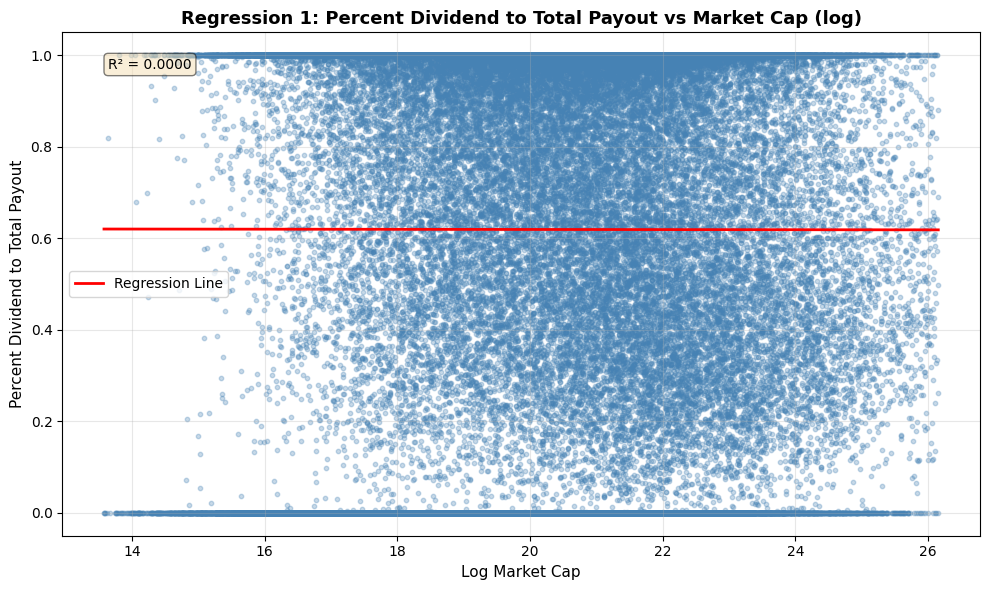


REGRESSION 2: Percent Buyback to Total Payout vs Market Cap (log)

Sample size: 94,177 observations

                                 OLS Regression Results                                
Dep. Variable:     pct_buyback_to_total_payout   R-squared:                       0.000
Model:                                     OLS   Adj. R-squared:                 -0.000
Method:                          Least Squares   F-statistic:                   0.04988
Date:                         Sun, 02 Nov 2025   Prob (F-statistic):              0.823
Time:                                 21:31:58   Log-Likelihood:                -53349.
No. Observations:                        94177   AIC:                         1.067e+05
Df Residuals:                            94175   BIC:                         1.067e+05
Df Model:                                    1                                         
Covariance Type:                           hc3                                         
                  

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,pct_buyback_to_total_payout,log_market_cap,0.0000,-0.0000,0.000143,0.000642,0.223,0.8233,0.377879,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


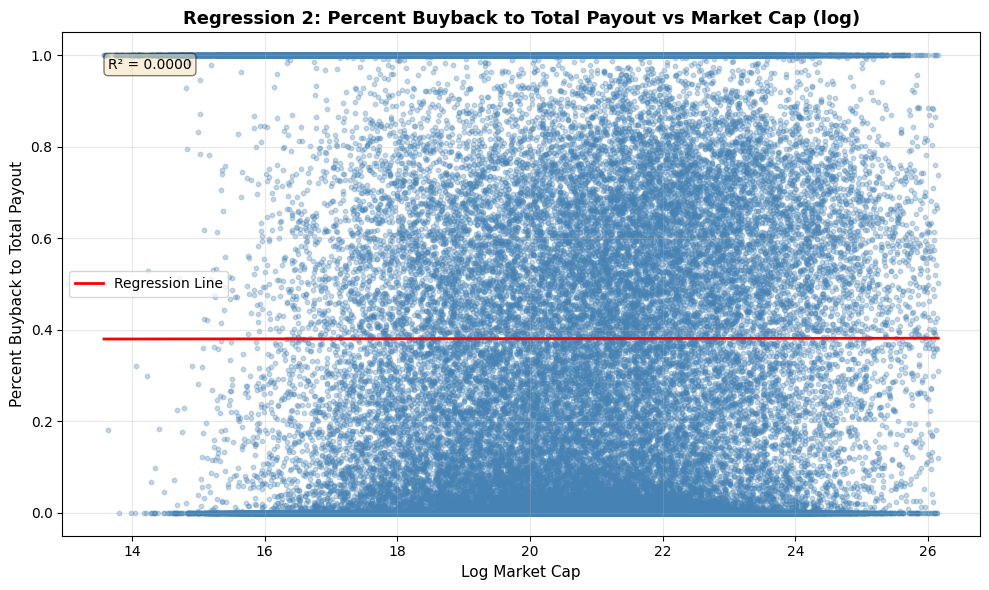


REGRESSION 3: Percent Dividend to Total Payout vs ROA

Sample size: 94,177 observations

                                 OLS Regression Results                                 
Dep. Variable:     pct_dividend_to_total_payout   R-squared:                       0.001
Model:                                      OLS   Adj. R-squared:                  0.001
Method:                           Least Squares   F-statistic:                     103.1
Date:                          Sun, 02 Nov 2025   Prob (F-statistic):           3.32e-24
Time:                                  21:31:59   Log-Likelihood:                -53290.
No. Observations:                         94177   AIC:                         1.066e+05
Df Residuals:                             94175   BIC:                         1.066e+05
Df Model:                                     1                                         
Covariance Type:                            hc3                                         
                 coe

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,pct_dividend_to_total_payout,roa,0.0013,0.0013,-0.324727,0.031984,-10.153,0.0000,0.632173,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


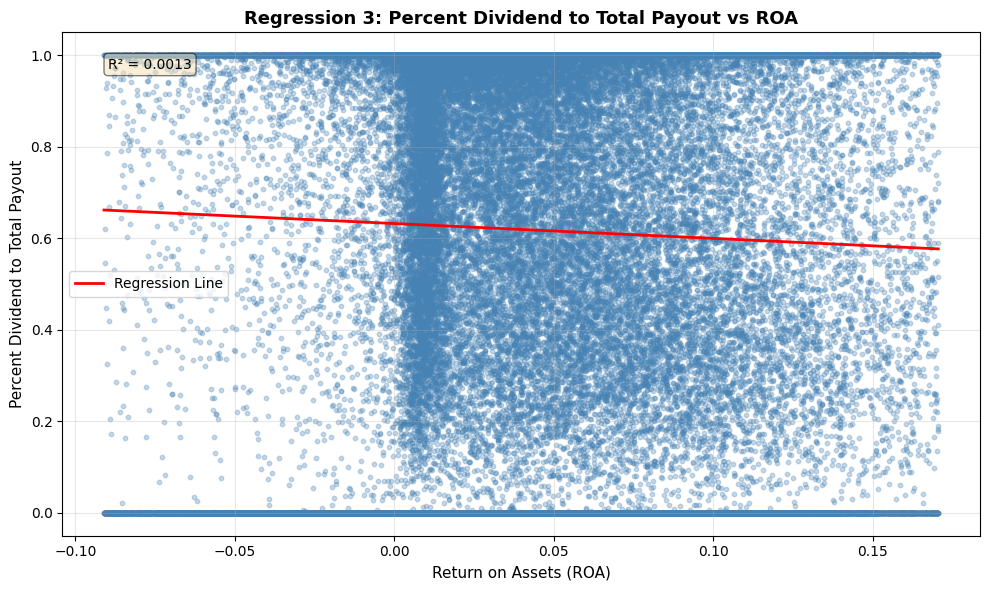


REGRESSION 4: Percent Buyback to Total Payout vs ROA

Sample size: 94,177 observations

                                 OLS Regression Results                                
Dep. Variable:     pct_buyback_to_total_payout   R-squared:                       0.001
Model:                                     OLS   Adj. R-squared:                  0.001
Method:                          Least Squares   F-statistic:                     103.1
Date:                         Sun, 02 Nov 2025   Prob (F-statistic):           3.32e-24
Time:                                 21:32:00   Log-Likelihood:                -53290.
No. Observations:                        94177   AIC:                         1.066e+05
Df Residuals:                            94175   BIC:                         1.066e+05
Df Model:                                    1                                         
Covariance Type:                           hc3                                         
                 coef    std er

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,pct_buyback_to_total_payout,roa,0.0013,0.0013,0.324727,0.031984,10.153,0.0000,0.367827,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


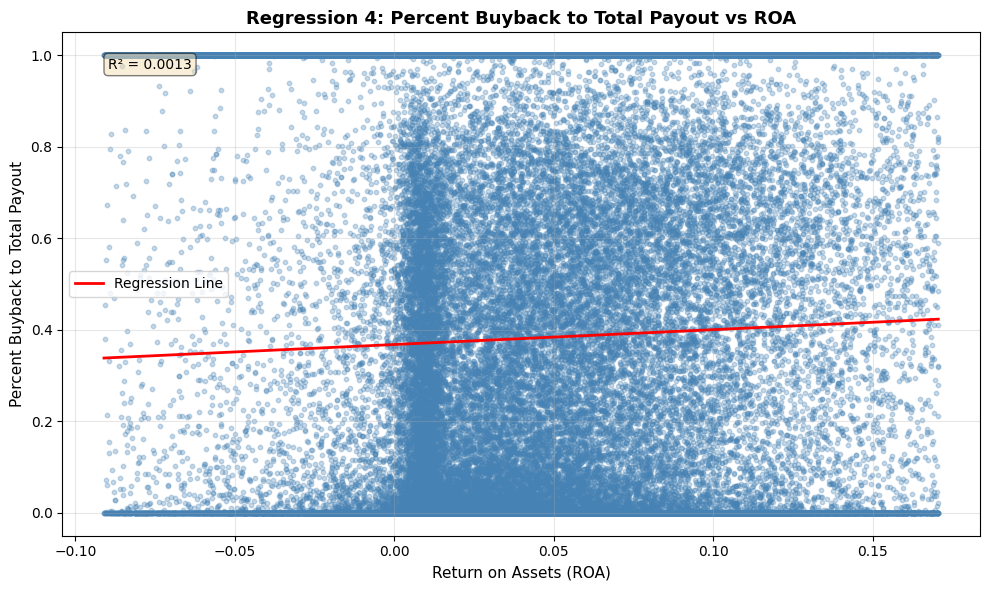


REGRESSION 5: Dividend Yield vs Size (log Market Cap)

Sample size: 94,177 observations

                            OLS Regression Results                            
Dep. Variable:         dividend_yield   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     39.51
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           3.28e-10
Time:                        21:32:01   Log-Likelihood:             1.5272e+06
No. Observations:               94177   AIC:                        -3.054e+06
Df Residuals:                   94175   BIC:                        -3.054e+06
Df Model:                           1                                         
Covariance Type:                  hc3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,dividend_yield,log_market_cap,0.0004,0.0004,0.000000,0.000000,6.285,0.0000,0.000000,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


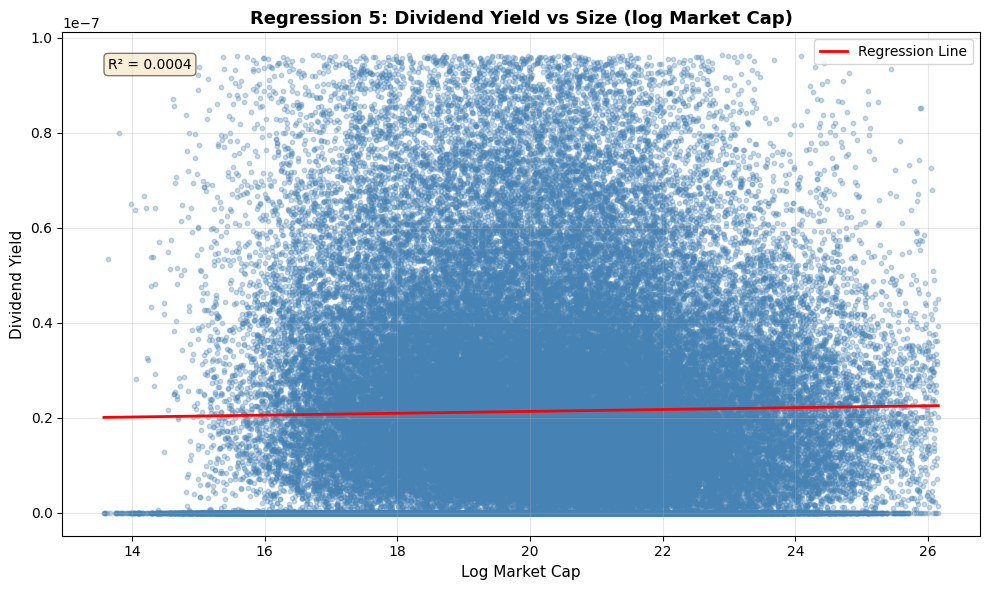


REGRESSION 6: Buyback to Market Cap vs Size (log Market Cap)

Sample size: 94,177 observations

                            OLS Regression Results                            
Dep. Variable:        buyback_to_mcap   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1303.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):          2.13e-283
Time:                        21:32:02   Log-Likelihood:             1.5633e+06
No. Observations:               94177   AIC:                        -3.127e+06
Df Residuals:                   94175   BIC:                        -3.127e+06
Df Model:                           1                                         
Covariance Type:                  hc3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,buyback_to_mcap,log_market_cap,0.0153,0.0153,0.000000,0.000000,36.098,0.0000,-0.000000,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


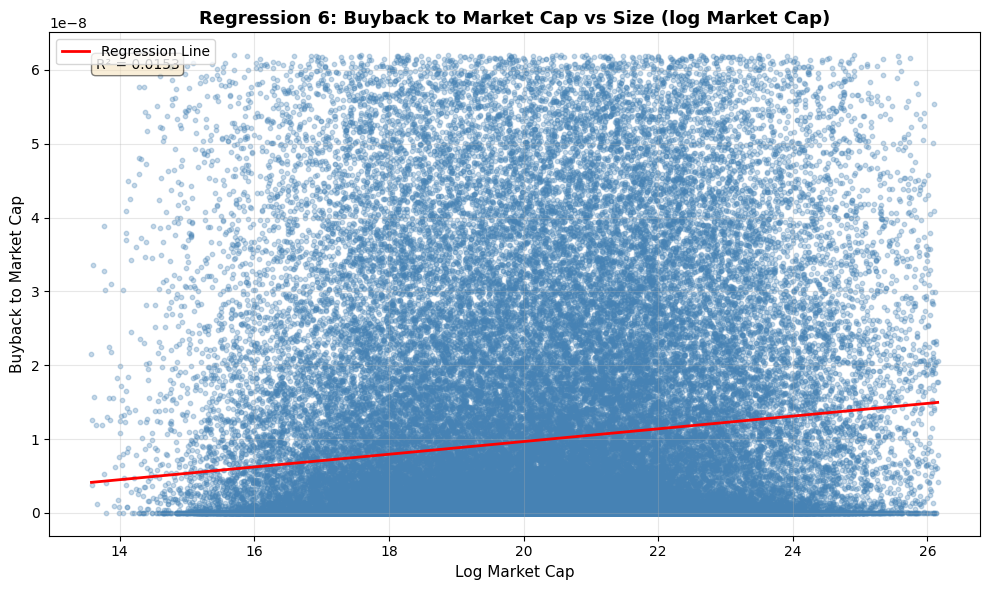


REGRESSION 7: Dividend Yield vs ROA

Sample size: 94,177 observations

                            OLS Regression Results                            
Dep. Variable:         dividend_yield   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     242.1
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           1.58e-54
Time:                        21:32:03   Log-Likelihood:             1.5273e+06
No. Observations:               94177   AIC:                        -3.055e+06
Df Residuals:                   94175   BIC:                        -3.055e+06
Df Model:                           1                                         
Covariance Type:                  hc3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,dividend_yield,roa,0.0024,0.0024,-0.000000,0.000000,-15.561,0.0000,0.000000,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


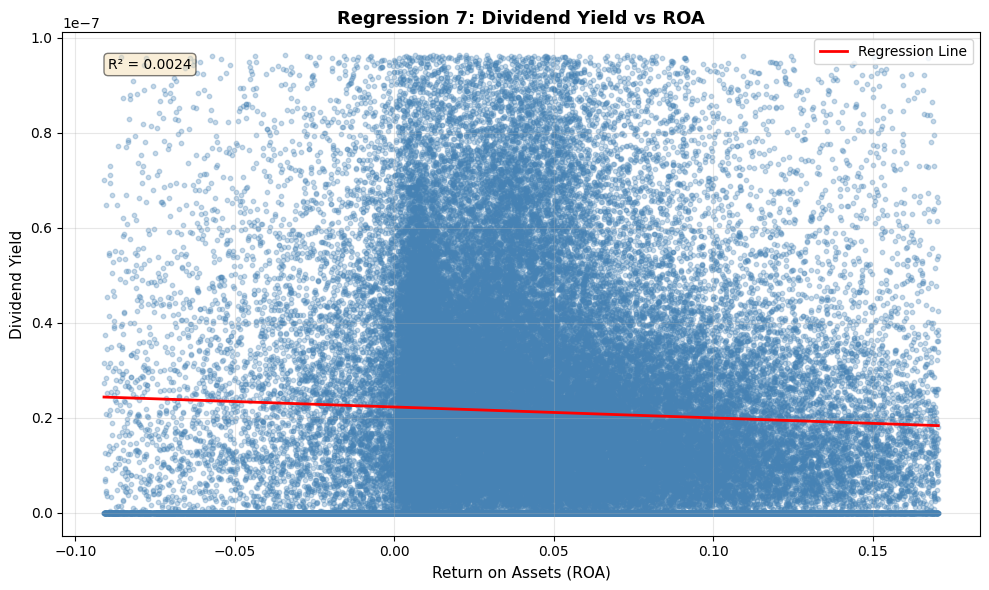


REGRESSION 8: Buyback to Market Cap vs ROA

Sample size: 94,177 observations

                            OLS Regression Results                            
Dep. Variable:        buyback_to_mcap   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1102.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):          2.57e-240
Time:                        21:32:04   Log-Likelihood:             1.5632e+06
No. Observations:               94177   AIC:                        -3.126e+06
Df Residuals:                   94175   BIC:                        -3.126e+06
Df Model:                           1                                         
Covariance Type:                  hc3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:124: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,buyback_to_mcap,roa,0.0127,0.0127,0.000000,0.000000,33.201,0.0000,0.000000,"94,177"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/380960505.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_sorted


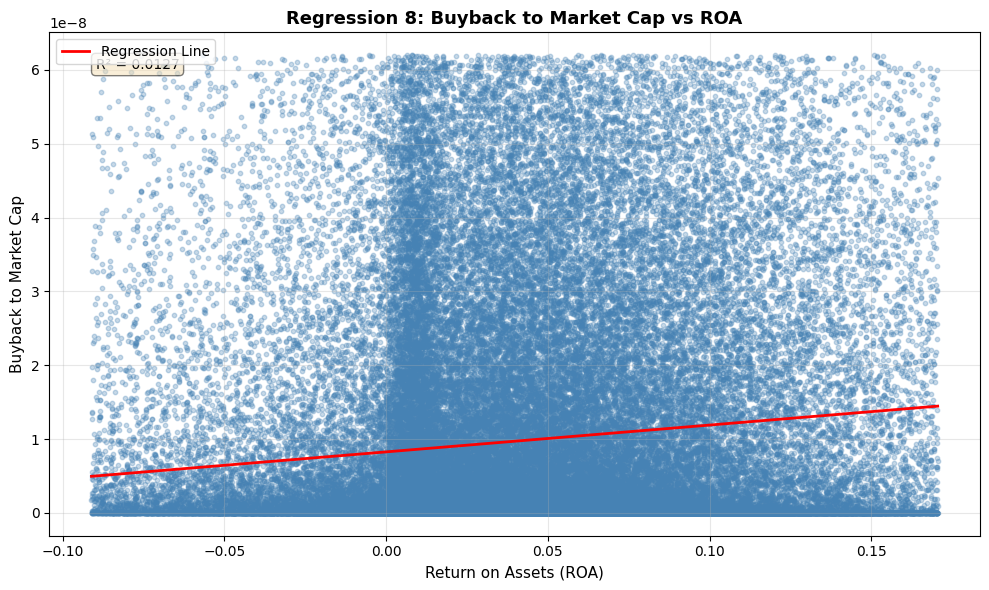


ALL REGRESSIONS COMPLETE


In [56]:
"""
Step 11: Regression Analysis - Payout Policy Determinants

This step creates regression models to understand the relationship between:
1. Percent dividend/buyback to total payout vs Market Cap and ROA
2. Dividend yield and buyback ratio vs Size and ROA
"""

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

print("=" * 80)
print("STEP 11: REGRESSION ANALYSIS")
print("=" * 80)

# Prepare data for regression
# Filter out rows with missing values for key variables
# AND exclude "no_payout" observations
reg_data = final_data[
    final_data['market_cap'].notna() & 
    final_data['roa'].notna() &
    (final_data['dividends'].notna() | final_data['buyback'].notna()) &
    (final_data['payout_type'] != 'no_payout')  # Exclude no_payout firms
].copy()

print(f"\nInitial sample size (before outlier removal): {len(reg_data):,} observations")
print(f"Date range: {reg_data['month'].min()} to {reg_data['month'].max()}")

# Function to remove outliers using IQR method
def remove_outliers_iqr(df, columns, factor=1.5):
    """Remove outliers using Interquartile Range (IQR) method"""
    df_clean = df.copy()
    initial_len = len(df_clean)
    
    for col in columns:
        if col not in df_clean.columns:
            continue
            
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Count outliers before removal
        n_outliers = len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])
        
        # Remove outliers
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        if n_outliers > 0:
            print(f"  Removed {n_outliers:,} outliers from {col}")
    
    removed = initial_len - len(df_clean)
    print(f"\nTotal outliers removed: {removed:,} observations ({removed/initial_len*100:.2f}%)")
    
    return df_clean

# Create total payout variable
reg_data['total_payout'] = reg_data['dividends'].fillna(0) + reg_data['buyback'].fillna(0)

# Create percentage variables (only for observations with positive total payout)
reg_data['pct_dividend_to_total_payout'] = np.where(
    reg_data['total_payout'] > 0,
    reg_data['dividends'].fillna(0) / reg_data['total_payout'],
    np.nan
)
reg_data['pct_buyback_to_total_payout'] = np.where(
    reg_data['total_payout'] > 0,
    reg_data['buyback'].fillna(0) / reg_data['total_payout'],
    np.nan
)

# Create yield/ratio variables
reg_data['dividend_yield'] = np.where(
    reg_data['market_cap'] > 0,
    reg_data['dividends'].fillna(0) / reg_data['market_cap'],
    np.nan
)
reg_data['buyback_to_mcap'] = np.where(
    reg_data['market_cap'] > 0,
    reg_data['buyback'].fillna(0) / reg_data['market_cap'],
    np.nan
)

# Use log market cap for better regression (avoid extreme outliers)
reg_data['log_market_cap'] = np.log(reg_data['market_cap'].clip(lower=1))  # Avoid log(0)

# Remove outliers from key regression variables (after creating all variables)
print("\nRemoving outliers using IQR method (factor=1.5)...")
print("Variables being cleaned:")

reg_data = remove_outliers_iqr(
    reg_data, 
    columns=['log_market_cap', 'roa', 'dividend_yield', 'buyback_to_mcap', 
             'pct_dividend_to_total_payout', 'pct_buyback_to_total_payout'],
    factor=1.5
)

print(f"\nFinal sample size (after outlier removal): {len(reg_data):,} observations")

print("\n" + "=" * 80)
print("Variable Creation Complete")
print("=" * 80)
print(f"\nSummary statistics for key variables:")
summary_cols = ['market_cap', 'log_market_cap', 'roa', 'total_payout', 
                'pct_dividend_to_total_payout', 'pct_buyback_to_total_payout',
                'dividend_yield', 'buyback_to_mcap']
print(reg_data[summary_cols].describe())

import matplotlib.pyplot as plt

# Function to create regression summary table
def create_regression_table(model, dep_var, indep_var):
    """Create a nice summary table for regression results"""
    results = {
        'Dependent Variable': [dep_var],
        'Independent Variable': [indep_var],
        'R-squared': [f"{model.rsquared:.4f}"],
        'Adj. R-squared': [f"{model.rsquared_adj:.4f}"],
        'Coefficient': [f"{model.params[1]:.6f}"],
        'Std Error': [f"{model.bse[1]:.6f}"],
        't-statistic': [f"{model.tvalues[1]:.3f}"],
        'P-value': [f"{model.pvalues[1]:.4f}"],
        'Intercept': [f"{model.params[0]:.6f}"],
        'N': [f"{model.nobs:,.0f}"]
    }
    return pd.DataFrame(results)

# Function to create scatterplot with regression line
def plot_regression(x, y, model, title, xlabel, ylabel, figsize=(10, 6)):
    """Create scatterplot with regression line"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    
    # Add regression line
    x_sorted = np.sort(x.values)
    y_pred = model.params[0] + model.params[1] * x_sorted
    ax.plot(x_sorted, y_pred, color='red', linewidth=2, label='Regression Line')
    
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add R² text
    r2_text = f"R² = {model.rsquared:.4f}"
    ax.text(0.05, 0.95, r2_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("REGRESSION 1: Percent Dividend to Total Payout vs Market Cap (log)")
print("=" * 80)

# Filter for observations with positive total payout
reg1_data = reg_data[reg_data['pct_dividend_to_total_payout'].notna() & 
                      reg_data['log_market_cap'].notna()].copy()
print(f"\nSample size: {len(reg1_data):,} observations")

# Prepare data
X1 = sm.add_constant(reg1_data['log_market_cap'])
y1 = reg1_data['pct_dividend_to_total_payout']

# Run regression
model1 = OLS(y1, X1).fit(cov_type='hc3')
print("\n" + model1.summary().as_text())

# Create summary table
reg1_table = create_regression_table(model1, 'pct_dividend_to_total_payout', 'log_market_cap')
print("\nSummary Table:")
display(reg1_table)

# Create scatterplot
plot_regression(reg1_data['log_market_cap'], y1, model1,
                'Regression 1: Percent Dividend to Total Payout vs Market Cap (log)',
                'Log Market Cap', 'Percent Dividend to Total Payout')

print("\n" + "=" * 80)
print("REGRESSION 2: Percent Buyback to Total Payout vs Market Cap (log)")
print("=" * 80)

# Filter for observations with positive total payout
reg2_data = reg_data[reg_data['pct_buyback_to_total_payout'].notna() & 
                      reg_data['log_market_cap'].notna()].copy()
print(f"\nSample size: {len(reg2_data):,} observations")

# Prepare data
X2 = sm.add_constant(reg2_data['log_market_cap'])
y2 = reg2_data['pct_buyback_to_total_payout']

# Run regression
model2 = OLS(y2, X2).fit(cov_type='hc3')
print("\n" + model2.summary().as_text())

# Create summary table
reg2_table = create_regression_table(model2, 'pct_buyback_to_total_payout', 'log_market_cap')
print("\nSummary Table:")
display(reg2_table)

# Create scatterplot
plot_regression(reg2_data['log_market_cap'], y2, model2,
                'Regression 2: Percent Buyback to Total Payout vs Market Cap (log)',
                'Log Market Cap', 'Percent Buyback to Total Payout')

print("\n" + "=" * 80)
print("REGRESSION 3: Percent Dividend to Total Payout vs ROA")
print("=" * 80)

# Filter for observations with positive total payout
reg3_data = reg_data[reg_data['pct_dividend_to_total_payout'].notna() & 
                      reg_data['roa'].notna()].copy()
print(f"\nSample size: {len(reg3_data):,} observations")

# Prepare data
X3 = sm.add_constant(reg3_data['roa'])
y3 = reg3_data['pct_dividend_to_total_payout']

# Run regression
model3 = OLS(y3, X3).fit(cov_type='hc3')
print("\n" + model3.summary().as_text())

# Create summary table
reg3_table = create_regression_table(model3, 'pct_dividend_to_total_payout', 'roa')
print("\nSummary Table:")
display(reg3_table)

# Create scatterplot
plot_regression(reg3_data['roa'], y3, model3,
                'Regression 3: Percent Dividend to Total Payout vs ROA',
                'Return on Assets (ROA)', 'Percent Dividend to Total Payout')

print("\n" + "=" * 80)
print("REGRESSION 4: Percent Buyback to Total Payout vs ROA")
print("=" * 80)

# Filter for observations with positive total payout
reg4_data = reg_data[reg_data['pct_buyback_to_total_payout'].notna() & 
                      reg_data['roa'].notna()].copy()
print(f"\nSample size: {len(reg4_data):,} observations")

# Prepare data
X4 = sm.add_constant(reg4_data['roa'])
y4 = reg4_data['pct_buyback_to_total_payout']

# Run regression
model4 = OLS(y4, X4).fit(cov_type='hc3')
print("\n" + model4.summary().as_text())

# Create summary table
reg4_table = create_regression_table(model4, 'pct_buyback_to_total_payout', 'roa')
print("\nSummary Table:")
display(reg4_table)

# Create scatterplot
plot_regression(reg4_data['roa'], y4, model4,
                'Regression 4: Percent Buyback to Total Payout vs ROA',
                'Return on Assets (ROA)', 'Percent Buyback to Total Payout')

print("\n" + "=" * 80)
print("REGRESSION 5: Dividend Yield vs Size (log Market Cap)")
print("=" * 80)

# Filter for observations with dividend yield
reg5_data = reg_data[
    reg_data['dividend_yield'].notna() & 
    reg_data['log_market_cap'].notna()
].copy()
print(f"\nSample size: {len(reg5_data):,} observations")

# Prepare data
X5 = sm.add_constant(reg5_data['log_market_cap'])
y5 = reg5_data['dividend_yield']

# Run regression
model5 = OLS(y5, X5).fit(cov_type='hc3')
print("\n" + model5.summary().as_text())

# Create summary table
reg5_table = create_regression_table(model5, 'dividend_yield', 'log_market_cap')
print("\nSummary Table:")
display(reg5_table)

# Create scatterplot
plot_regression(reg5_data['log_market_cap'], y5, model5,
                'Regression 5: Dividend Yield vs Size (log Market Cap)',
                'Log Market Cap', 'Dividend Yield')

print("\n" + "=" * 80)
print("REGRESSION 6: Buyback to Market Cap vs Size (log Market Cap)")
print("=" * 80)

# Filter for observations with buyback to market cap
reg6_data = reg_data[
    reg_data['buyback_to_mcap'].notna() & 
    reg_data['log_market_cap'].notna()
].copy()
print(f"\nSample size: {len(reg6_data):,} observations")

# Prepare data
X6 = sm.add_constant(reg6_data['log_market_cap'])
y6 = reg6_data['buyback_to_mcap']

# Run regression
model6 = OLS(y6, X6).fit(cov_type='hc3')
print("\n" + model6.summary().as_text())

# Create summary table
reg6_table = create_regression_table(model6, 'buyback_to_mcap', 'log_market_cap')
print("\nSummary Table:")
display(reg6_table)

# Create scatterplot
plot_regression(reg6_data['log_market_cap'], y6, model6,
                'Regression 6: Buyback to Market Cap vs Size (log Market Cap)',
                'Log Market Cap', 'Buyback to Market Cap')

print("\n" + "=" * 80)
print("REGRESSION 7: Dividend Yield vs ROA")
print("=" * 80)

# Filter for observations with dividend yield and ROA
reg7_data = reg_data[
    reg_data['dividend_yield'].notna() & 
    reg_data['roa'].notna()
].copy()
print(f"\nSample size: {len(reg7_data):,} observations")

# Prepare data
X7 = sm.add_constant(reg7_data['roa'])
y7 = reg7_data['dividend_yield']

# Run regression
model7 = OLS(y7, X7).fit(cov_type='hc3')
print("\n" + model7.summary().as_text())

# Create summary table
reg7_table = create_regression_table(model7, 'dividend_yield', 'roa')
print("\nSummary Table:")
display(reg7_table)

# Create scatterplot
plot_regression(reg7_data['roa'], y7, model7,
                'Regression 7: Dividend Yield vs ROA',
                'Return on Assets (ROA)', 'Dividend Yield')

print("\n" + "=" * 80)
print("REGRESSION 8: Buyback to Market Cap vs ROA")
print("=" * 80)

# Filter for observations with buyback to market cap and ROA
reg8_data = reg_data[
    reg_data['buyback_to_mcap'].notna() & 
    reg_data['roa'].notna()
].copy()
print(f"\nSample size: {len(reg8_data):,} observations")

# Prepare data
X8 = sm.add_constant(reg8_data['roa'])
y8 = reg8_data['buyback_to_mcap']

# Run regression
model8 = OLS(y8, X8).fit(cov_type='hc3')
print("\n" + model8.summary().as_text())

# Create summary table
reg8_table = create_regression_table(model8, 'buyback_to_mcap', 'roa')
print("\nSummary Table:")
display(reg8_table)

# Create scatterplot
plot_regression(reg8_data['roa'], y8, model8,
                'Regression 8: Buyback to Market Cap vs ROA',
                'Return on Assets (ROA)', 'Buyback to Market Cap')

print("\n" + "=" * 80)
print("ALL REGRESSIONS COMPLETE")
print("=" * 80)



STEP 12: EXECUTIVE TIMING ANALYSIS - BUYBACKS AND FUTURE RETURNS

Initial sample size: 59,994 observations
Date range: 1982-01-31 00:00:00 to 2023-12-31 00:00:00

Removing outliers from key variables...
Sample size after outlier removal: 53,442 observations

Buyback intensity stats:
count    5.344200e+04
mean     2.978975e-08
std      3.036747e-08
min      1.074638e-13
25%      5.475078e-09
50%      1.974000e-08
75%      4.438767e-08
max      1.319157e-07
Name: buyback_intensity, dtype: float64

Future 1-year return stats:
count    53442.000000
mean         0.114665
std          0.152839
min         -0.343648
25%          0.020277
50%          0.134057
75%          0.234543
max          0.537143
Name: ret_1y, dtype: float64

ANALYSIS 1: Portfolio Analysis by Buyback Intensity Quintiles

Future 1-Year Returns by Buyback Intensity Quintile:


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_returns = timing_data.groupby('buyback_intensity_quintile')['ret_1y'].agg([


,buyback_intensity_quintile,mean_return,median_return,std_return,count,mean_return_pct
2,Q3,0.1148,0.1341,0.1529,10594,11.4759
0,Q1 (Lowest),0.1147,0.1341,0.1527,10886,11.4705
4,Q5 (Highest),0.1147,0.1341,0.1529,10780,11.4654
3,Q4,0.1146,0.1341,0.1529,10591,11.4604
1,Q2,0.1146,0.1341,0.1529,10591,11.4601



Difference (Highest - Lowest Quintile): 0.02 percentage points

ANALYSIS 2: Regression Analysis - Buyback Intensity on Future Returns

Sample size for regression: 53,442 observations

                            OLS Regression Results                            
Dep. Variable:                 ret_1y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     13.54
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           0.000233
Time:                        21:37:34   Log-Likelihood:                 24560.
No. Observations:               53442   AIC:                        -4.912e+04
Df Residuals:                   53440   BIC:                        -4.910e+04
Df Model:                           1                                         
Covariance Type:                  hc3                                         
                        c

/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Coefficient': [f"{model_timing.params[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Std Error': [f"{model_timing.bse[1]:.6f}"],
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:123: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

,Dependent Variable,Independent Variable,R-squared,Adj. R-squared,Coefficient,Std Error,t-statistic,P-value,Intercept,N
0,Future 1-Year Return,Buyback Intensity,0.0003,0.0002,80266.396244,21811.362406,3.680,0.0002,0.112274,"53,442"


/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:146: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = (model_timing.params[0] + model_timing.params[1] * x_sorted) * 100
/var/folders/r2/6cdy00j57gn8hn927bvk72kc0000gn/T/ipykernel_63736/2578128604.py:157: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r2_text = f"R² = {model_timing.rsquared:.4f}\nCoefficient = {model_timing.params[1]:.6f}\nP-value = {model_timing.pvalues[1]:.4f}"



VISUALIZATIONS


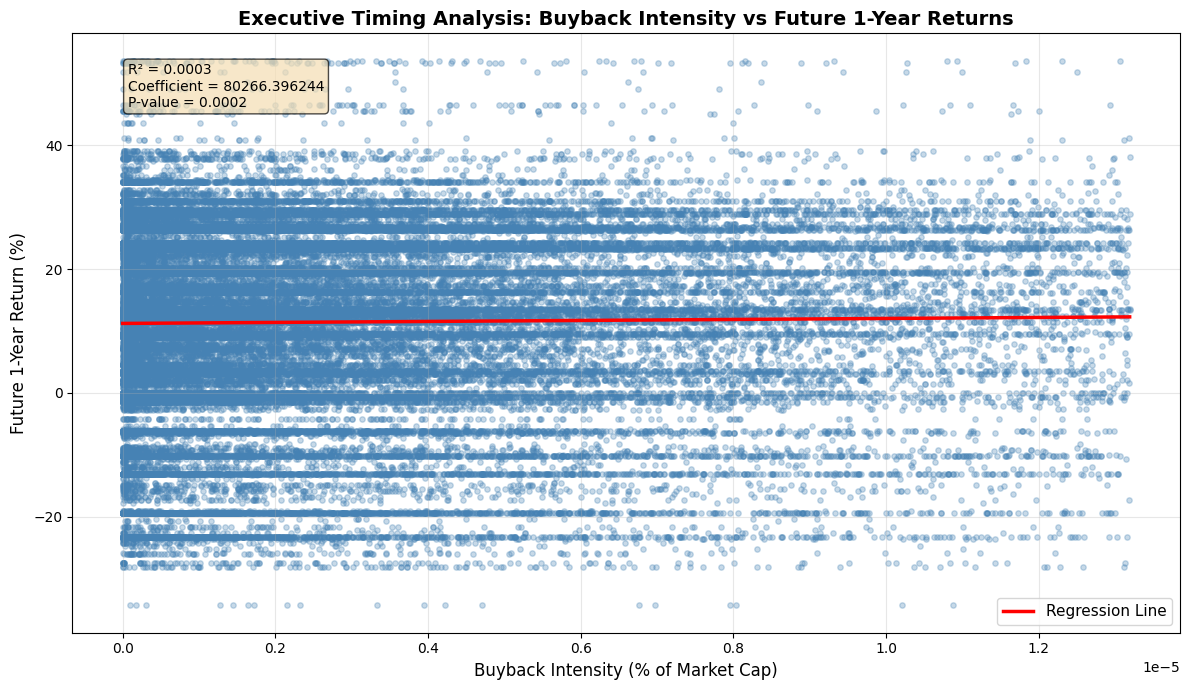

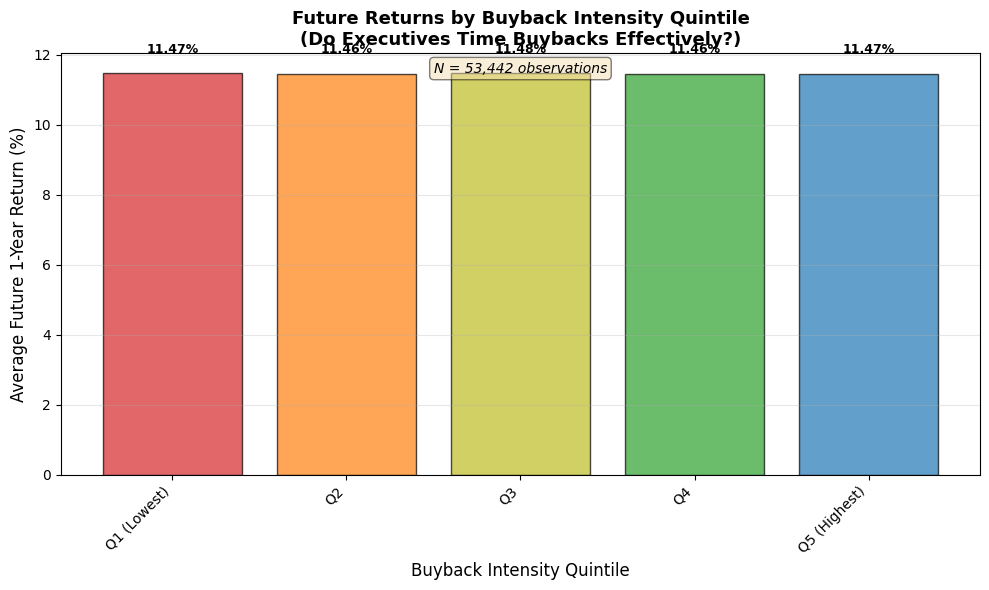


ANALYSIS COMPLETE

Interpretation:
If executives are savvy at timing buybacks:
- Higher buyback intensity should predict higher future returns
- The regression coefficient should be positive and significant
- Higher quintiles should show higher average future returns


In [57]:
"""
Step 12: Executive Timing Analysis - Do Buybacks Predict Future Returns?

This step investigates whether executives can time buybacks effectively by examining
if higher relative buybacks (buyback_to_mcap) lead to higher future 1-year returns.

Hypothesis: If executives are savvy, higher buyback intensity should predict 
higher future returns, suggesting they buy back stock when prices are low.
"""

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt

print("=" * 80)
print("STEP 12: EXECUTIVE TIMING ANALYSIS - BUYBACKS AND FUTURE RETURNS")
print("=" * 80)

# Prepare data for timing analysis
# We need: buyback intensity at time t and future 1-year return
timing_data = final_data[
    final_data['buyback'].notna() &
    final_data['market_cap'].notna() &
    final_data['ret_1y'].notna() &
    final_data['payout_type'].isin(['buyback', 'mixed'])  # Focus on firms that do buybacks
].copy()

print(f"\nInitial sample size: {len(timing_data):,} observations")
print(f"Date range: {timing_data['month'].min()} to {timing_data['month'].max()}")

# Create buyback intensity variable (buyback relative to market cap)
timing_data['buyback_intensity'] = np.where(
    timing_data['market_cap'] > 0,
    timing_data['buyback'] / timing_data['market_cap'],
    np.nan
)

# Remove extreme outliers using IQR method
print("\nRemoving outliers from key variables...")
Q1_intensity = timing_data['buyback_intensity'].quantile(0.25)
Q3_intensity = timing_data['buyback_intensity'].quantile(0.75)
IQR_intensity = Q3_intensity - Q1_intensity
lower_intensity = Q1_intensity - 1.5 * IQR_intensity
upper_intensity = Q3_intensity + 1.5 * IQR_intensity

Q1_return = timing_data['ret_1y'].quantile(0.25)
Q3_return = timing_data['ret_1y'].quantile(0.75)
IQR_return = Q3_return - Q1_return
lower_return = Q1_return - 1.5 * IQR_return
upper_return = Q3_return + 1.5 * IQR_return

timing_data = timing_data[
    (timing_data['buyback_intensity'] >= lower_intensity) &
    (timing_data['buyback_intensity'] <= upper_intensity) &
    (timing_data['ret_1y'] >= lower_return) &
    (timing_data['ret_1y'] <= upper_return)
].copy()

print(f"Sample size after outlier removal: {len(timing_data):,} observations")
print(f"\nBuyback intensity stats:")
print(timing_data['buyback_intensity'].describe())
print(f"\nFuture 1-year return stats:")
print(timing_data['ret_1y'].describe())

print("\n" + "=" * 80)
print("ANALYSIS 1: Portfolio Analysis by Buyback Intensity Quintiles")
print("=" * 80)

# Create quintiles based on buyback intensity within each month
# This controls for time-varying market conditions
timing_data['buyback_intensity_quintile'] = timing_data.groupby('month')['buyback_intensity'].transform(
    lambda x: pd.qcut(x, q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'], duplicates='drop')
)

# Calculate average future returns by quintile
quintile_returns = timing_data.groupby('buyback_intensity_quintile')['ret_1y'].agg([
    ('mean_return', 'mean'),
    ('median_return', 'median'),
    ('std_return', 'std'),
    ('count', 'count')
]).reset_index()

quintile_returns['mean_return_pct'] = quintile_returns['mean_return'] * 100
quintile_returns = quintile_returns.sort_values('mean_return', ascending=False)

print("\nFuture 1-Year Returns by Buyback Intensity Quintile:")
display(quintile_returns.round(4))

# Calculate difference between highest and lowest quintile
if len(quintile_returns) >= 2:
    high_low_diff = (quintile_returns['mean_return'].iloc[0] - 
                     quintile_returns['mean_return'].iloc[-1]) * 100
    print(f"\nDifference (Highest - Lowest Quintile): {high_low_diff:.2f} percentage points")

print("\n" + "=" * 80)
print("ANALYSIS 2: Regression Analysis - Buyback Intensity on Future Returns")
print("=" * 80)

# Prepare data for regression
reg_timing_data = timing_data[
    timing_data['buyback_intensity'].notna() &
    timing_data['ret_1y'].notna()
].copy()

print(f"\nSample size for regression: {len(reg_timing_data):,} observations")

# Regression: Future 1-year return ~ Buyback Intensity
X_timing = sm.add_constant(reg_timing_data['buyback_intensity'])
y_timing = reg_timing_data['ret_1y']

# Run regression
model_timing = OLS(y_timing, X_timing).fit(cov_type='hc3')
print("\n" + model_timing.summary().as_text())

# Create summary table
timing_table = pd.DataFrame({
    'Dependent Variable': ['Future 1-Year Return'],
    'Independent Variable': ['Buyback Intensity'],
    'R-squared': [f"{model_timing.rsquared:.4f}"],
    'Adj. R-squared': [f"{model_timing.rsquared_adj:.4f}"],
    'Coefficient': [f"{model_timing.params[1]:.6f}"],
    'Std Error': [f"{model_timing.bse[1]:.6f}"],
    't-statistic': [f"{model_timing.tvalues[1]:.3f}"],
    'P-value': [f"{model_timing.pvalues[1]:.4f}"],
    'Intercept': [f"{model_timing.params[0]:.6f}"],
    'N': [f"{model_timing.nobs:,.0f}"]
})

print("\nSummary Table:")
display(timing_table)

print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

# Visualization 1: Scatterplot with regression line
fig, ax = plt.subplots(figsize=(12, 7))

# Create scatter plot
ax.scatter(reg_timing_data['buyback_intensity'] * 100, 
           reg_timing_data['ret_1y'] * 100, 
           alpha=0.3, s=15, color='steelblue')

# Add regression line
x_sorted = np.sort(reg_timing_data['buyback_intensity'].values)
y_pred = (model_timing.params[0] + model_timing.params[1] * x_sorted) * 100
ax.plot(x_sorted * 100, y_pred, color='red', linewidth=2.5, label='Regression Line')

ax.set_xlabel('Buyback Intensity (% of Market Cap)', fontsize=12)
ax.set_ylabel('Future 1-Year Return (%)', fontsize=12)
ax.set_title('Executive Timing Analysis: Buyback Intensity vs Future 1-Year Returns', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add R² and coefficient text
r2_text = f"R² = {model_timing.rsquared:.4f}\nCoefficient = {model_timing.params[1]:.6f}\nP-value = {model_timing.pvalues[1]:.4f}"
ax.text(0.05, 0.95, r2_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

# Visualization 2: Portfolio Returns by Quintile (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

# Sort quintiles in order
quintile_order = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']
quintile_returns_sorted = quintile_returns.set_index('buyback_intensity_quintile').reindex(
    [q for q in quintile_order if q in quintile_returns['buyback_intensity_quintile'].values]
).reset_index()

x_pos = np.arange(len(quintile_returns_sorted))
bars = ax.bar(x_pos, quintile_returns_sorted['mean_return_pct'], 
              color=['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4'],
              alpha=0.7, edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(quintile_returns_sorted['buyback_intensity_quintile'], rotation=45, ha='right')
ax.set_ylabel('Average Future 1-Year Return (%)', fontsize=12)
ax.set_xlabel('Buyback Intensity Quintile', fontsize=12)
ax.set_title('Future Returns by Buyback Intensity Quintile\n(Do Executives Time Buybacks Effectively?)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add value labels
for i, (idx, row) in enumerate(quintile_returns_sorted.iterrows()):
    val = row['mean_return_pct']
    ax.text(i, val + 0.5 if val >= 0 else val - 0.5, f'{val:.2f}%',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold')

# Add sample size info
n_total = timing_data['ret_1y'].notna().sum()
ax.text(0.5, 0.98, f'N = {n_total:,} observations',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nInterpretation:")
print("If executives are savvy at timing buybacks:")
print("- Higher buyback intensity should predict higher future returns")
print("- The regression coefficient should be positive and significant")
print("- Higher quintiles should show higher average future returns")
print("=" * 80)

